# Import :

In [2]:
import joblib

import scipy as sp
from scipy.stats import skew, boxcox, mode
from scipy.spatial import distance
import cvxpy as cp

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import missingno as msno
from sklearn.impute import SimpleImputer 

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, ElasticNet, Lasso, RidgeCV, LassoCV, ElasticNetCV, LogisticRegression, SGDClassifier
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer, PowerTransformer, FunctionTransformer, QuantileTransformer, LabelEncoder, OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn import metrics
from sklearn.utils.extmath import weighted_mode
from sklearn.model_selection import train_test_split, KFold, LeaveOneOut, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.datasets import load_breast_cancer, make_classification, make_blobs, make_circles, load_iris, make_regression
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.svm import LinearSVC, SVC, NuSVC
from sklearn.neighbors import KDTree, BallTree, NearestNeighbors

from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.basemap import Basemap
from scipy.ndimage import gaussian_filter1d
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

from mlxtend.evaluate import bias_variance_decomp

In [2]:
def Mean_Absolute_Deviation(df):
    MAD = np.abs(df - df.mean()).mean()
    return MAD

In [3]:
def Median_Absolute_Deviation(df):
    MAD = np.abs(df - df.median()).median()
    return MAD

# Preprocessing Data :

## Load DataSet :

In [3]:
df = pd.read_csv("../data/bank-full.csv", sep=';')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [6]:
df[df.dtypes[(df.dtypes == 'object')].index] = df.loc[:, (df.dtypes == 'object')].astype('category')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        45211 non-null  int64   
 1   job        45211 non-null  category
 2   marital    45211 non-null  category
 3   education  45211 non-null  category
 4   default    45211 non-null  category
 5   balance    45211 non-null  int64   
 6   housing    45211 non-null  category
 7   loan       45211 non-null  category
 8   contact    45211 non-null  category
 9   day        45211 non-null  int64   
 10  month      45211 non-null  category
 11  duration   45211 non-null  int64   
 12  campaign   45211 non-null  int64   
 13  pdays      45211 non-null  int64   
 14  previous   45211 non-null  int64   
 15  poutcome   45211 non-null  category
 16  y          45211 non-null  category
dtypes: category(10), int64(7)
memory usage: 2.8 MB


In [8]:
df.iloc[:, [16]].value_counts(), display(df.iloc[:, [16]])

,y
0,no
1,no
2,no
3,no
4,no
...,...
45206,yes
45207,yes
45208,yes
45209,no


(y  
 no     39922
 yes     5289
 Name: count, dtype: int64,
 None)

## Train_Test Split :

In [9]:
train_set, test_set = train_test_split(df, train_size=0.8, random_state=100, stratify=df.iloc[:, -1])
train_set.shape, test_set.shape

((36168, 17), (9043, 17))

In [10]:
train_set, vall_set = train_test_split(train_set, train_size=0.8, random_state=100, stratify=train_set.iloc[:, -1])
train_set.shape, vall_set.shape

((28934, 17), (7234, 17))

(array([6388.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
         846.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

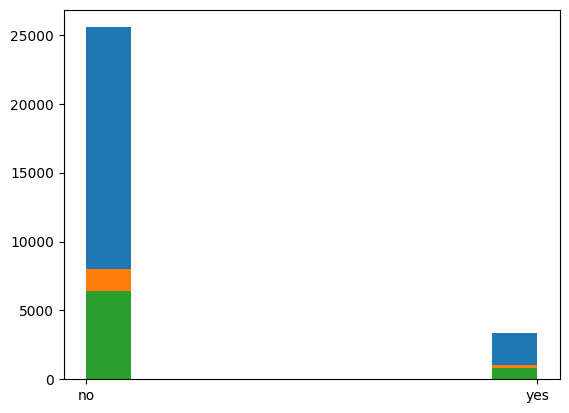

In [11]:
plt.hist(train_set.iloc[:, -1])
plt.hist(test_set.iloc[:, -1])
plt.hist(vall_set.iloc[:, -1])

## Missing values :

In [12]:
train_set.isna().sum(axis=0)

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

<Axes: >

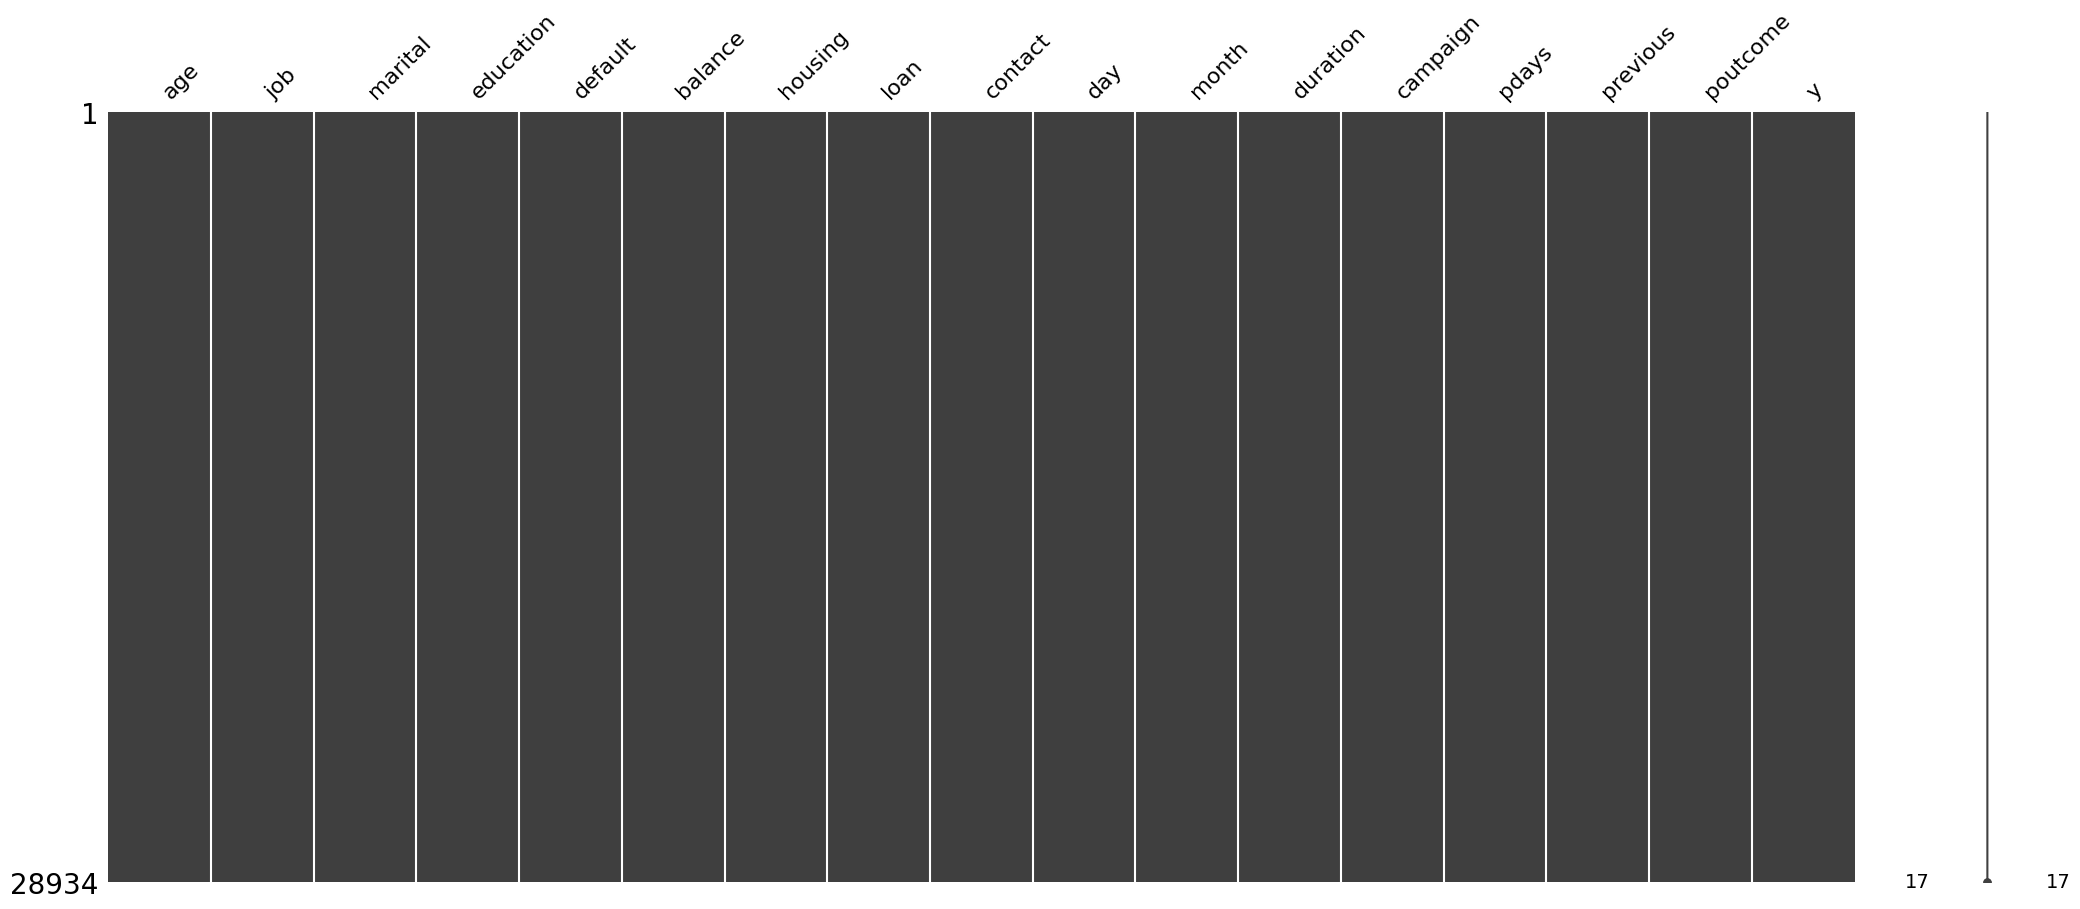

In [13]:
msno.matrix(train_set)

## Data Encoding :

In [14]:
train_set.select_dtypes('category').columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')

In [15]:
train_set_e = pd.get_dummies(train_set, columns=['job', 'marital', 'contact', 'poutcome'], dtype=np.float64)

In [16]:
encoder = LabelEncoder()
train_set_e.education = encoder.fit_transform(train_set_e.education)
train_set_e.month = encoder.fit_transform(train_set_e.month)

In [17]:
train_set_e = pd.get_dummies(train_set_e, columns=['default', 'housing', 'loan'], dtype=np.float64, drop_first=True)

In [18]:
train_set_e = pd.get_dummies(train_set_e, columns=['y'], dtype=np.int64, drop_first=True)

In [19]:
train_set_e

,age,education,balance,day,month,duration,campaign,pdays,previous,job_admin.,...,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown,default_yes,housing_yes,loan_yes,y_yes
5295,34,1,5547,23,8,313,1,-1,0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0
44593,40,2,15,22,1,4,1,-1,0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0
2269,32,1,1466,12,8,264,2,-1,0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0
22496,49,1,682,22,1,86,4,-1,0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
29851,36,3,449,4,3,166,2,-1,0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15154,39,1,363,17,5,184,1,-1,0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0
591,38,1,581,6,8,79,1,-1,0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0
7684,50,1,2062,30,8,165,1,-1,0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
10765,50,3,1537,17,6,24,6,-1,0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0


In [20]:
sort_columns = ['age','job_admin.', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'marital_divorced', 'marital_married',
       'marital_single', 'education', 'default_yes', 'balance', 'housing_yes',
       'loan_yes', 'contact_cellular', 'contact_telephone',
       'contact_unknown', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'y_yes']

In [21]:
train_set_e = train_set_e.reindex(columns=sort_columns)

In [22]:
train_set_e[train_set_e.dtypes[train_set_e.dtypes == np.int64].index] = train_set_e[train_set_e.dtypes[train_set_e.dtypes == np.int64].index].astype(np.float64)

In [23]:
train_set_e

,age,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,...,contact_cellular,contact_telephone,contact_unknown,day,month,duration,campaign,pdays,previous,y_yes
5295,34.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,23.0,8.0,313.0,1.0,-1.0,0.0,0.0
44593,40.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,22.0,1.0,4.0,1.0,-1.0,0.0,0.0
2269,32.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,12.0,8.0,264.0,2.0,-1.0,0.0,0.0
22496,49.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,22.0,1.0,86.0,4.0,-1.0,0.0,0.0
29851,36.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,4.0,3.0,166.0,2.0,-1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15154,39.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,17.0,5.0,184.0,1.0,-1.0,0.0,0.0
591,38.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,6.0,8.0,79.0,1.0,-1.0,0.0,0.0
7684,50.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,30.0,8.0,165.0,1.0,-1.0,0.0,0.0
10765,50.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,17.0,6.0,24.0,6.0,-1.0,0.0,0.0


In [24]:
train_set_e.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28934 entries, 5295 to 5584
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                28934 non-null  float64
 1   job_admin.         28934 non-null  float64
 2   job_blue-collar    28934 non-null  float64
 3   job_entrepreneur   28934 non-null  float64
 4   job_housemaid      28934 non-null  float64
 5   job_management     28934 non-null  float64
 6   job_retired        28934 non-null  float64
 7   job_self-employed  28934 non-null  float64
 8   job_services       28934 non-null  float64
 9   job_student        28934 non-null  float64
 10  job_technician     28934 non-null  float64
 11  job_unemployed     28934 non-null  float64
 12  job_unknown        28934 non-null  float64
 13  marital_divorced   28934 non-null  float64
 14  marital_married    28934 non-null  float64
 15  marital_single     28934 non-null  float64
 16  education          28934 

## Exploratory Data Analysis (EDA) :

### univariabel:

#### describe :

In [25]:
des_train = train_set.describe()

In [26]:
des_train.loc['median'] = train_set.select_dtypes(exclude='category').median()
des_train.loc['mode'] = train_set.select_dtypes(exclude='category').mode().iloc[0, :]
des_train.loc['var'] = train_set.select_dtypes(exclude='category').var()
des_train.loc['MeanAD'] = Mean_Absolute_Deviation(train_set.select_dtypes(exclude='category'))
des_train.loc['MedianAD'] = Median_Absolute_Deviation(train_set.select_dtypes(exclude='category'))
des_train.loc['range'] = des_train.loc['max'] - des_train.loc['min']
des_train.loc['IQR'] = des_train.loc['75%'] - des_train.loc['25%']
des_train.loc['Upper cap'] = des_train.loc['75%'] + 3.5*des_train.loc['IQR']
des_train.loc['Lower cap'] = des_train.loc['25%'] - 3.5*des_train.loc['IQR']
des_train = des_train.reindex(index=['count', 'mean', 'median', 'mode', 'std', 'var', 'MeanAD', 'MedianAD', 'min', '25%', '50%', '75%', 'max', 'range', 'IQR', 'Upper cap', 'Lower cap'])

des_train

,age,balance,day,duration,campaign,pdays,previous
count,28934.000000,2.893400e+04,28934.000000,28934.000000,28934.000000,28934.000000,28934.000000
mean,40.956003,1.374274e+03,15.797539,258.411661,2.765950,40.224096,0.589272
median,39.000000,4.545000e+02,16.000000,180.000000,2.000000,-1.000000,0.000000
mode,32.000000,0.000000e+00,20.000000,89.000000,1.000000,-1.000000,0.000000
std,10.610838,3.052065e+03,8.320283,257.962075,3.127290,100.265050,2.523815
var,112.589880,9.315100e+06,69.227110,66544.431953,9.779940,10053.080253,6.369644
MeanAD,8.746554,1.565501e+03,7.050565,171.082650,1.791697,67.700165,0.963967
MedianAD,7.000000,4.545000e+02,7.000000,93.000000,1.000000,0.000000,0.000000
min,18.000000,-8.019000e+03,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,7.300000e+01,8.000000,104.000000,1.000000,-1.000000,0.000000


#### plot:

##### histogram :

In [27]:
train_set.shape

(28934, 17)

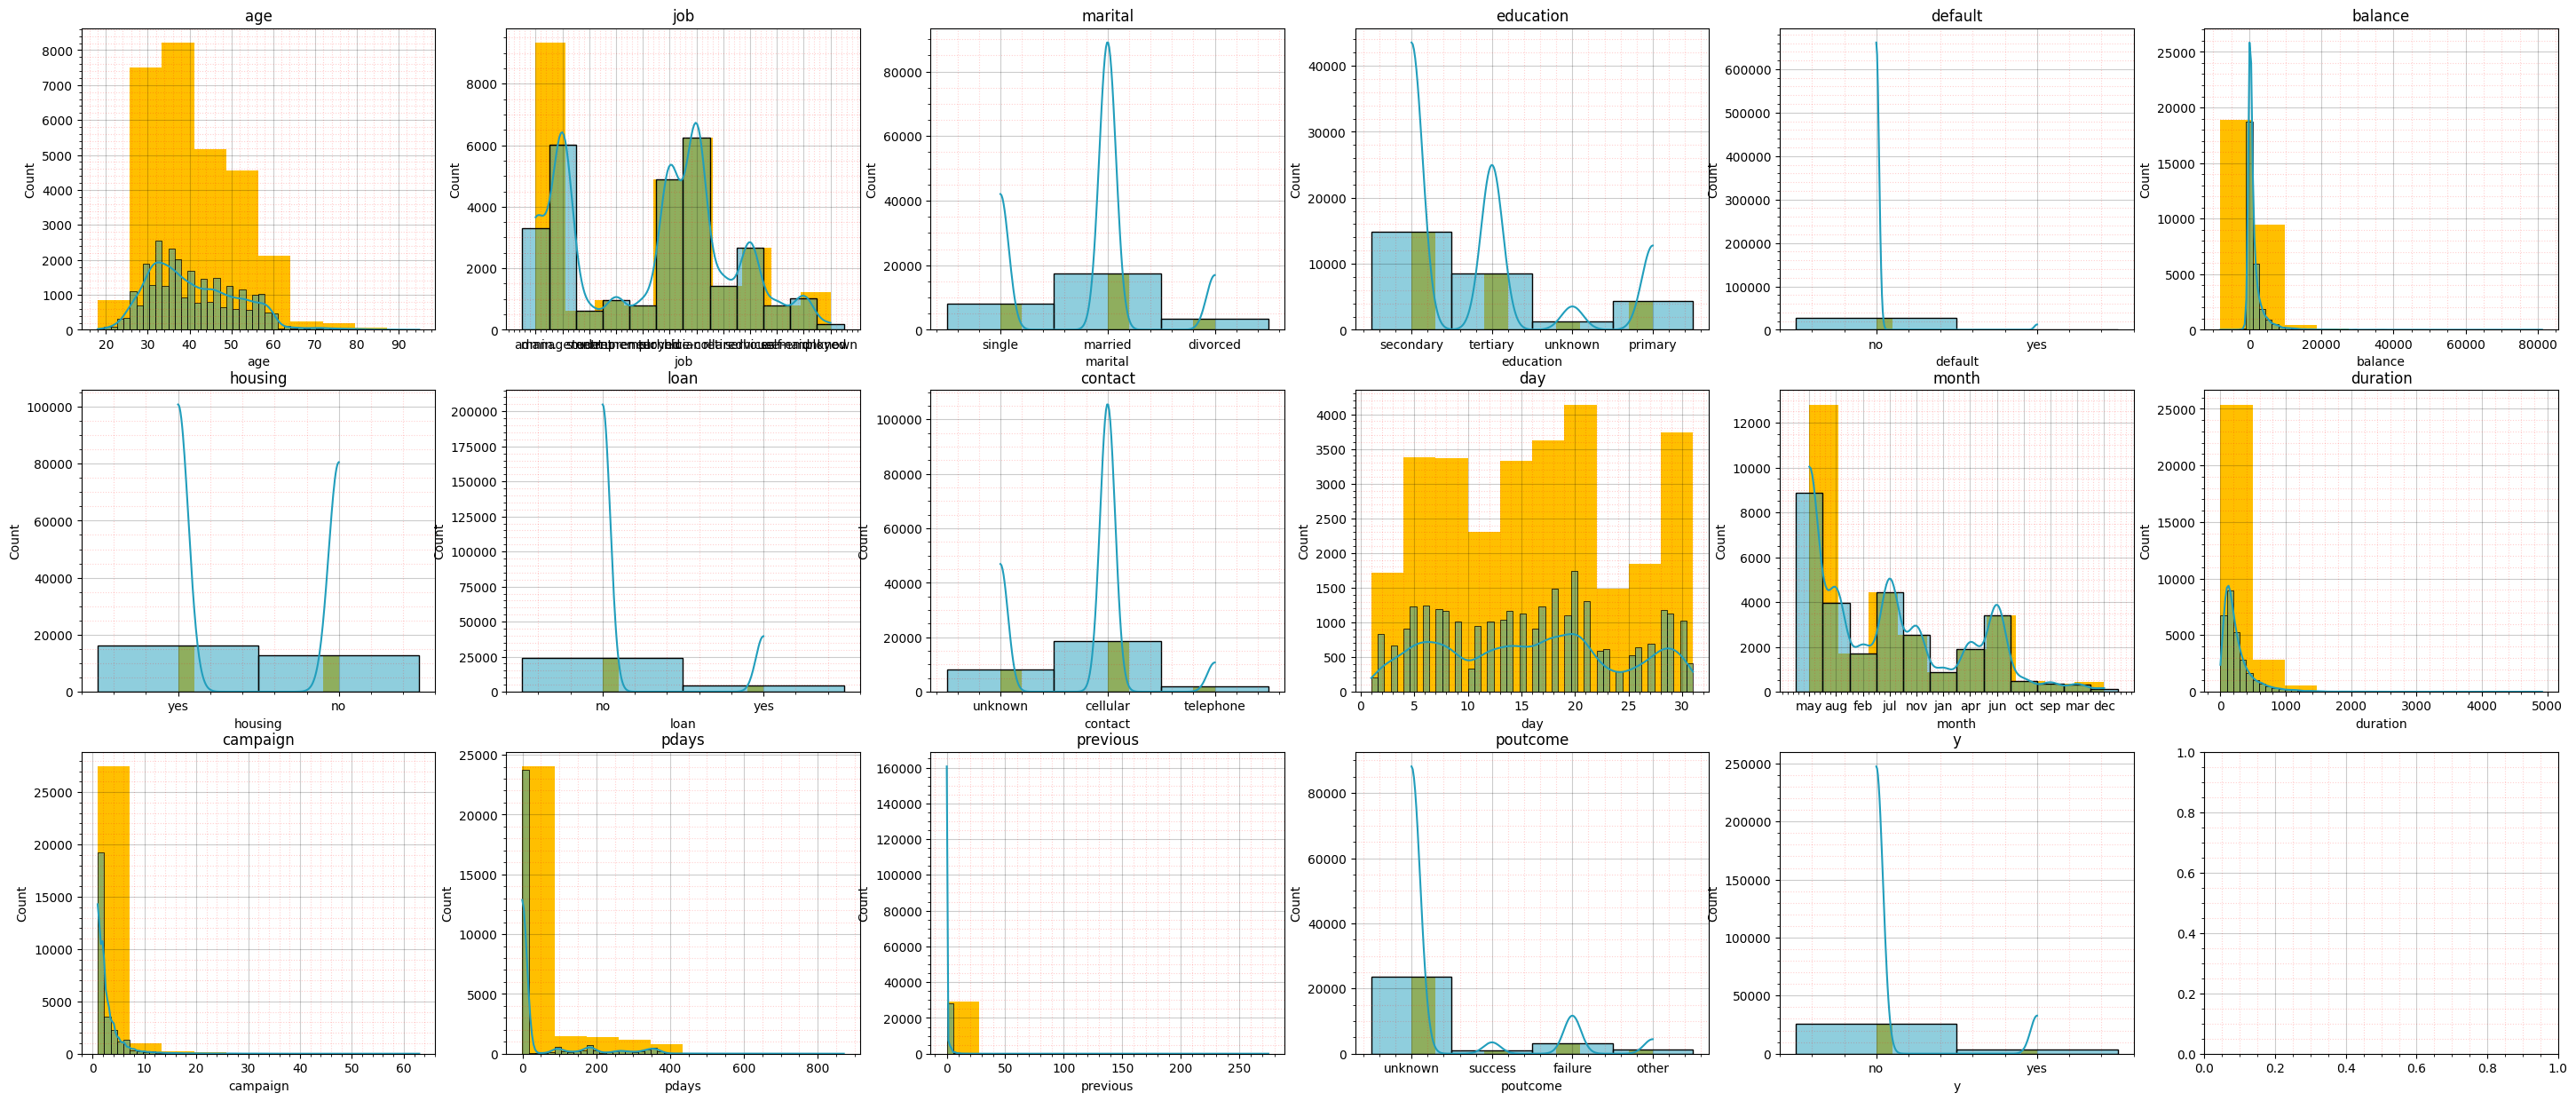

In [28]:
fig1, axs1 = plt.subplots(3, 6, figsize=(36, 15))

for i, e in enumerate([0, 6, 12]):
    for j in range(6):
        axs1[i, j].grid(which='minor', ls = ':', c = '#FF1111', alpha = 0.2)
        axs1[i, j].grid(c = 'k', alpha = 0.2)
        axs1[i, j].minorticks_on()

        if j + e < train_set.shape[1] :
            axs1[i, j].hist(train_set.iloc[:, j+e], color = '#FFBF00')
            axs1[i, j].set_title(train_set.columns[j+e])
            sns.histplot(train_set.iloc[:, j+e], color = '#219ebc', bins=50, kde=True, ax=axs1[i, j])

##### KDE :

In [29]:
train_numeric = train_set.select_dtypes(exclude='category')
train_numeric.shape

(28934, 7)

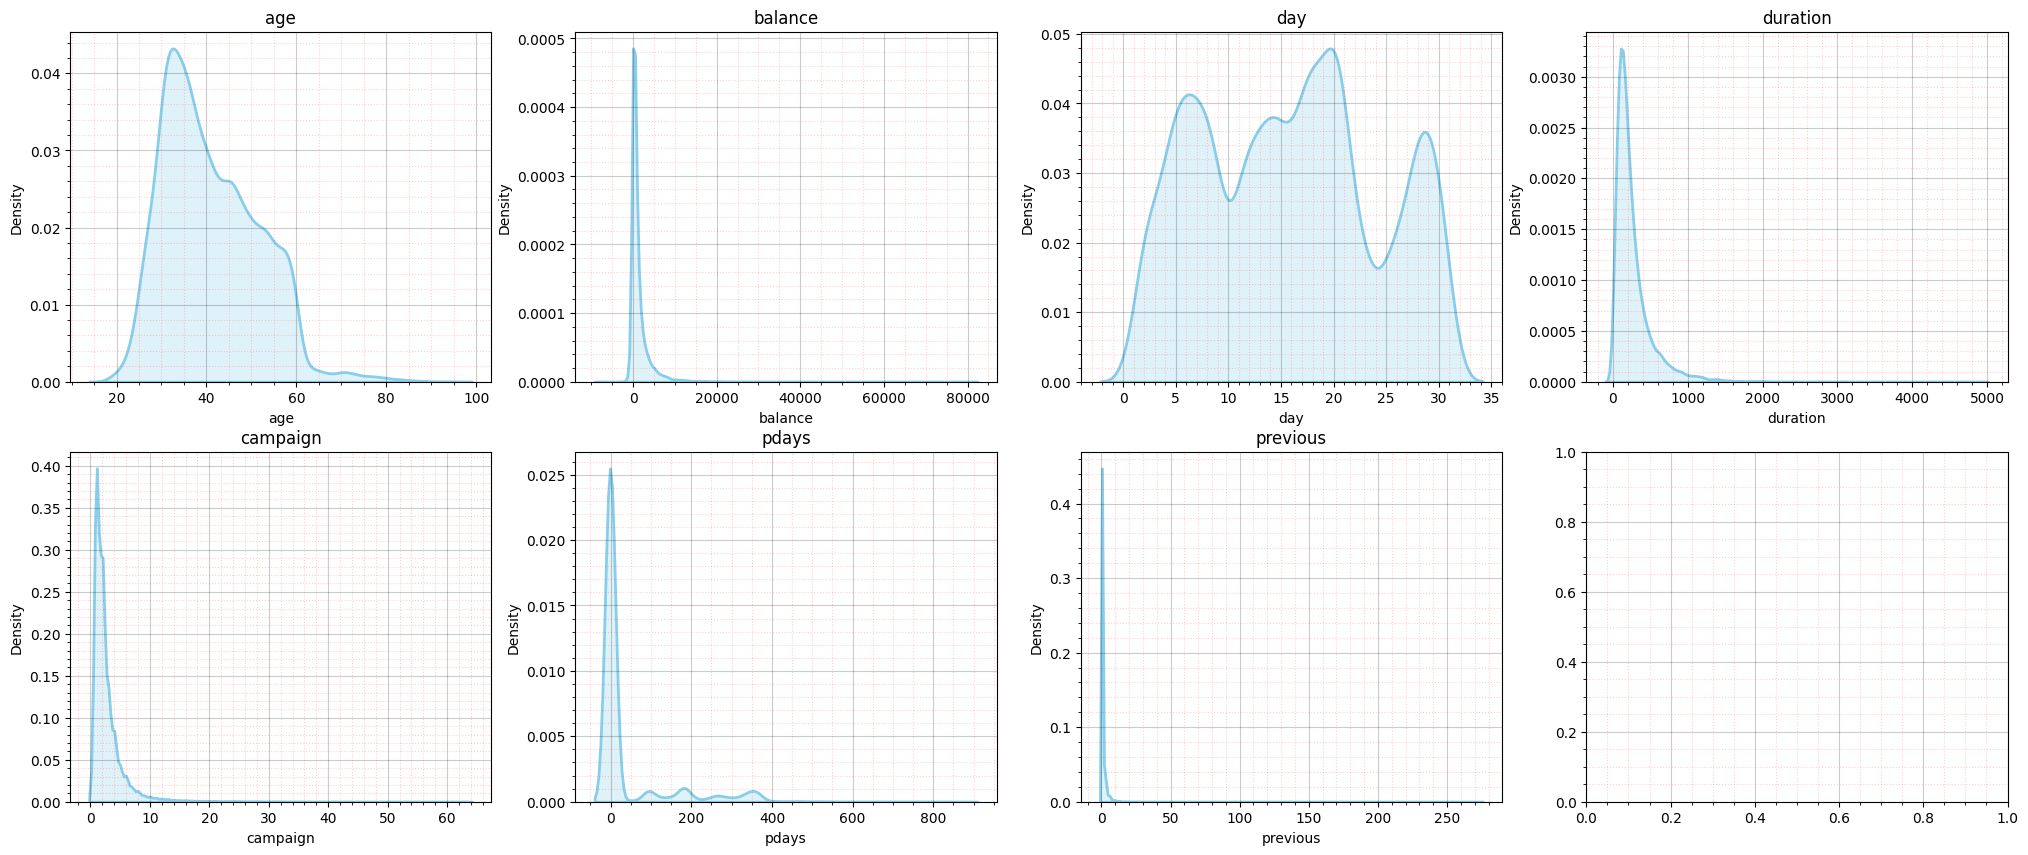

In [30]:
fig2, axs2 = plt.subplots(2, 4, figsize=(25, 10))

for i, e in enumerate([0, 4]):
    for j in range(4):
        axs2[i, j].grid(which='minor', ls = ':', c = '#FF1111', alpha = 0.2)
        axs2[i, j].grid(c = 'k', alpha = 0.2)
        axs2[i, j].minorticks_on()

        if (j + e) < train_numeric.shape[1] :
            sns.kdeplot(train_numeric.iloc[:, j+e], fill=True, color="skyblue", linewidth=2, ax=axs2[i, j])
            axs2[i, j].set_title(train_numeric.columns[j+e])

##### BoxPlot :

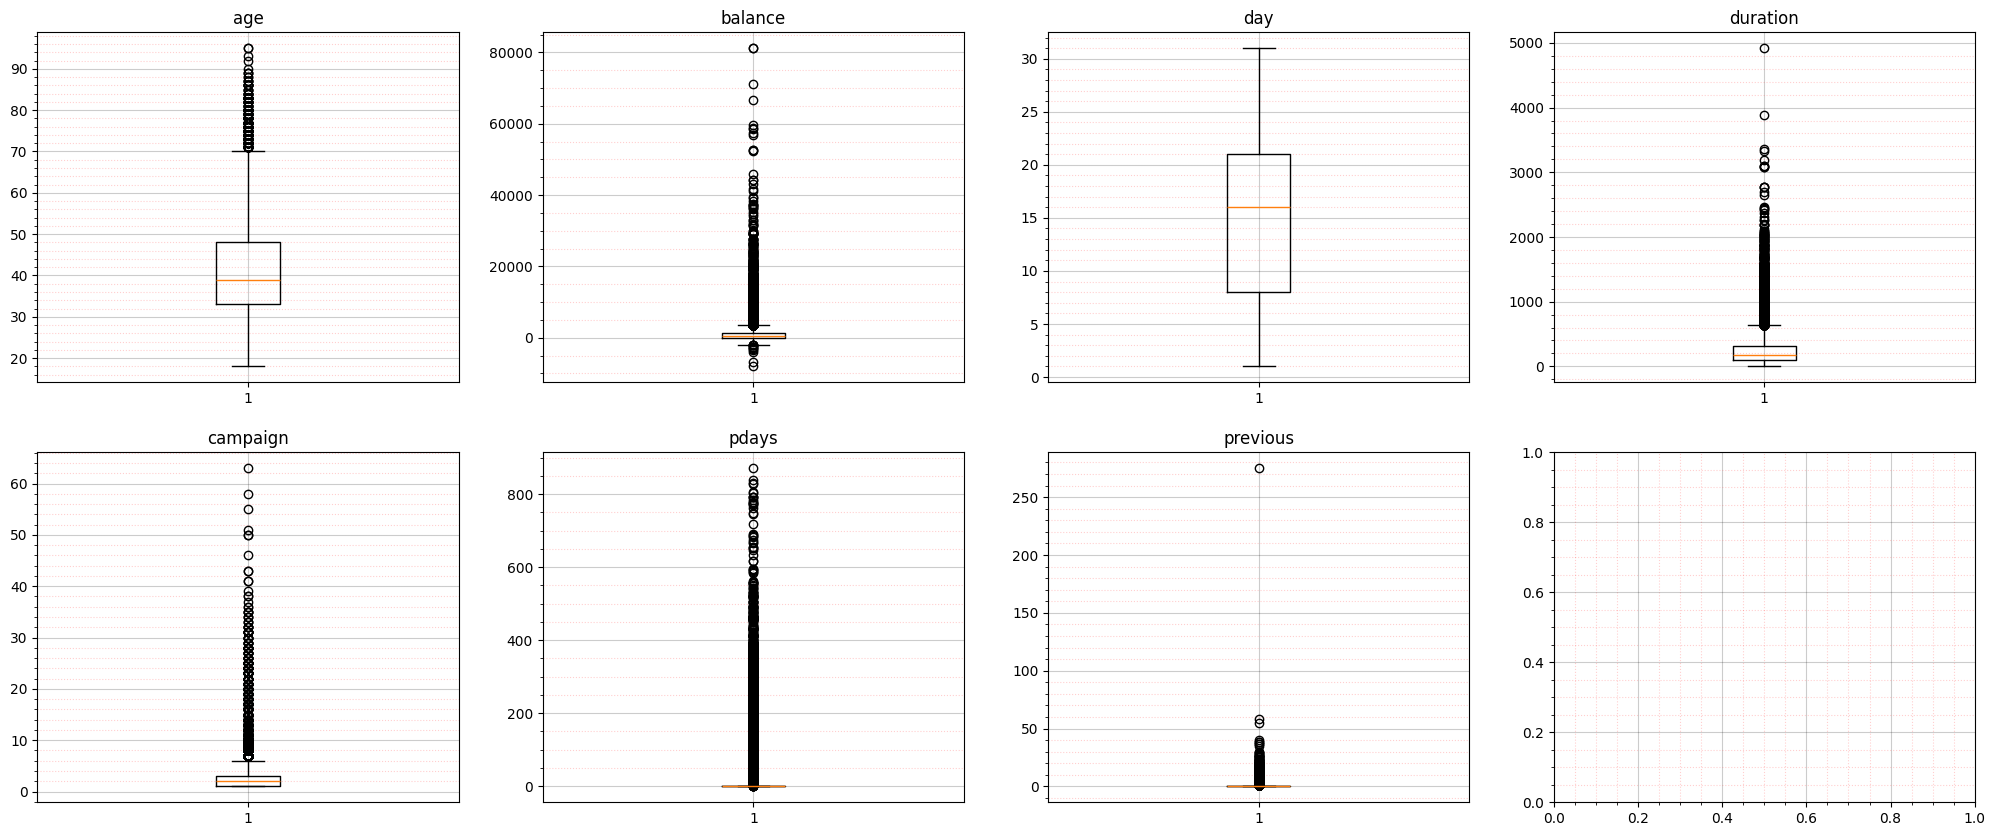

In [31]:
fig3, axs3 = plt.subplots(2, 4, figsize=(25, 10))

for i, e in enumerate([0, 4]):
    for j in range(4):
        axs3[i, j].grid(which='minor', ls = ':', c = '#FF1111', alpha = 0.2)
        axs3[i, j].grid(c = 'k', alpha = 0.2)
        axs3[i, j].minorticks_on()

        if (j + e) < train_numeric.shape[1] :
            axs3[i, j].boxplot(train_numeric.iloc[:, j+e])
            axs3[i, j].set_title(train_numeric.columns[j+e])

### two variabel :

#### Correlation :

In [32]:
train_set_e.corr()

,age,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,...,contact_cellular,contact_telephone,contact_unknown,day,month,duration,campaign,pdays,previous,y_yes
age,1.000000,-0.059468,-0.043422,0.021190,0.092084,-0.021982,0.441955,-0.007101,-0.063672,-0.198572,...,-0.074395,0.169561,-0.014302,-0.009542,-0.037240,-0.004087,0.005764,-0.021514,0.001448,0.028335
job_admin.,-0.059468,1.000000,-0.188412,-0.067105,-0.060088,-0.184344,-0.081546,-0.069005,-0.114339,-0.052912,...,0.000123,-0.010307,0.005516,-0.011161,0.035982,-0.013361,-0.019604,0.025684,0.011579,0.007055
job_blue-collar,-0.043422,-0.188412,1.000000,-0.097912,-0.087673,-0.268970,-0.118981,-0.100684,-0.166828,-0.077202,...,-0.126034,-0.007164,0.137047,-0.027411,0.088254,0.006267,0.013067,0.016735,-0.019262,-0.074755
job_entrepreneur,0.021190,-0.067105,-0.097912,1.000000,-0.031226,-0.095797,-0.042377,-0.035860,-0.059418,-0.027497,...,0.000007,-0.002390,0.001302,-0.003352,0.040868,-0.000851,0.006688,-0.009208,-0.002545,-0.016129
job_housemaid,0.092084,-0.060088,-0.087673,-0.031226,1.000000,-0.085779,-0.037945,-0.032110,-0.053205,-0.024621,...,-0.021039,0.043096,-0.001385,0.002384,-0.036006,-0.003551,0.002188,-0.036818,-0.016059,-0.020540
job_management,-0.021982,-0.184344,-0.268970,-0.095797,-0.085779,1.000000,-0.116412,-0.098510,-0.163226,-0.075535,...,0.099536,-0.027560,-0.090038,0.022691,-0.052804,-0.009400,0.009085,-0.001965,0.023768,0.035158
job_retired,0.441955,-0.081546,-0.118981,-0.042377,-0.037945,-0.116412,1.000000,-0.043576,-0.072204,-0.033413,...,-0.022799,0.109115,-0.035690,-0.011474,-0.022991,0.030978,-0.031256,-0.006674,0.002411,0.083820
job_self-employed,-0.007101,-0.069005,-0.100684,-0.035860,-0.032110,-0.098510,-0.043576,1.000000,-0.061100,-0.028275,...,0.012915,-0.001990,-0.012551,0.004606,-0.000658,0.011083,0.007927,-0.006815,-0.001210,-0.002545
job_services,-0.063672,-0.114339,-0.166828,-0.059418,-0.053205,-0.163226,-0.072204,-0.061100,1.000000,-0.046851,...,-0.027148,-0.013446,0.036040,-0.002407,0.041235,0.003374,-0.004874,0.007417,-0.011539,-0.026124
job_student,-0.198572,-0.052912,-0.077202,-0.027497,-0.024621,-0.075535,-0.033413,-0.028275,-0.046851,1.000000,...,0.026920,0.024810,-0.042025,-0.018380,0.002574,-0.004246,-0.019961,0.017851,0.021207,0.073992


In [33]:
train_set_e.corr().y_yes.abs().sort_values(ascending=False)

y_yes                1.000000
duration             0.398485
contact_unknown      0.145900
housing_yes          0.138817
contact_cellular     0.133297
pdays                0.102739
previous             0.091406
job_retired          0.083820
job_blue-collar      0.074755
job_student          0.073992
loan_yes             0.071894
campaign             0.071581
education            0.067247
marital_single       0.061839
marital_married      0.059756
balance              0.056936
job_management       0.035158
day                  0.028636
age                  0.028335
job_services         0.026124
month                0.023018
job_unemployed       0.021371
job_housemaid        0.020540
default_yes          0.019021
job_entrepreneur     0.016129
job_technician       0.009968
contact_telephone    0.009322
job_admin.           0.007055
marital_divorced     0.004311
job_self-employed    0.002545
job_unknown          0.000555
Name: y_yes, dtype: float64

<Axes: >

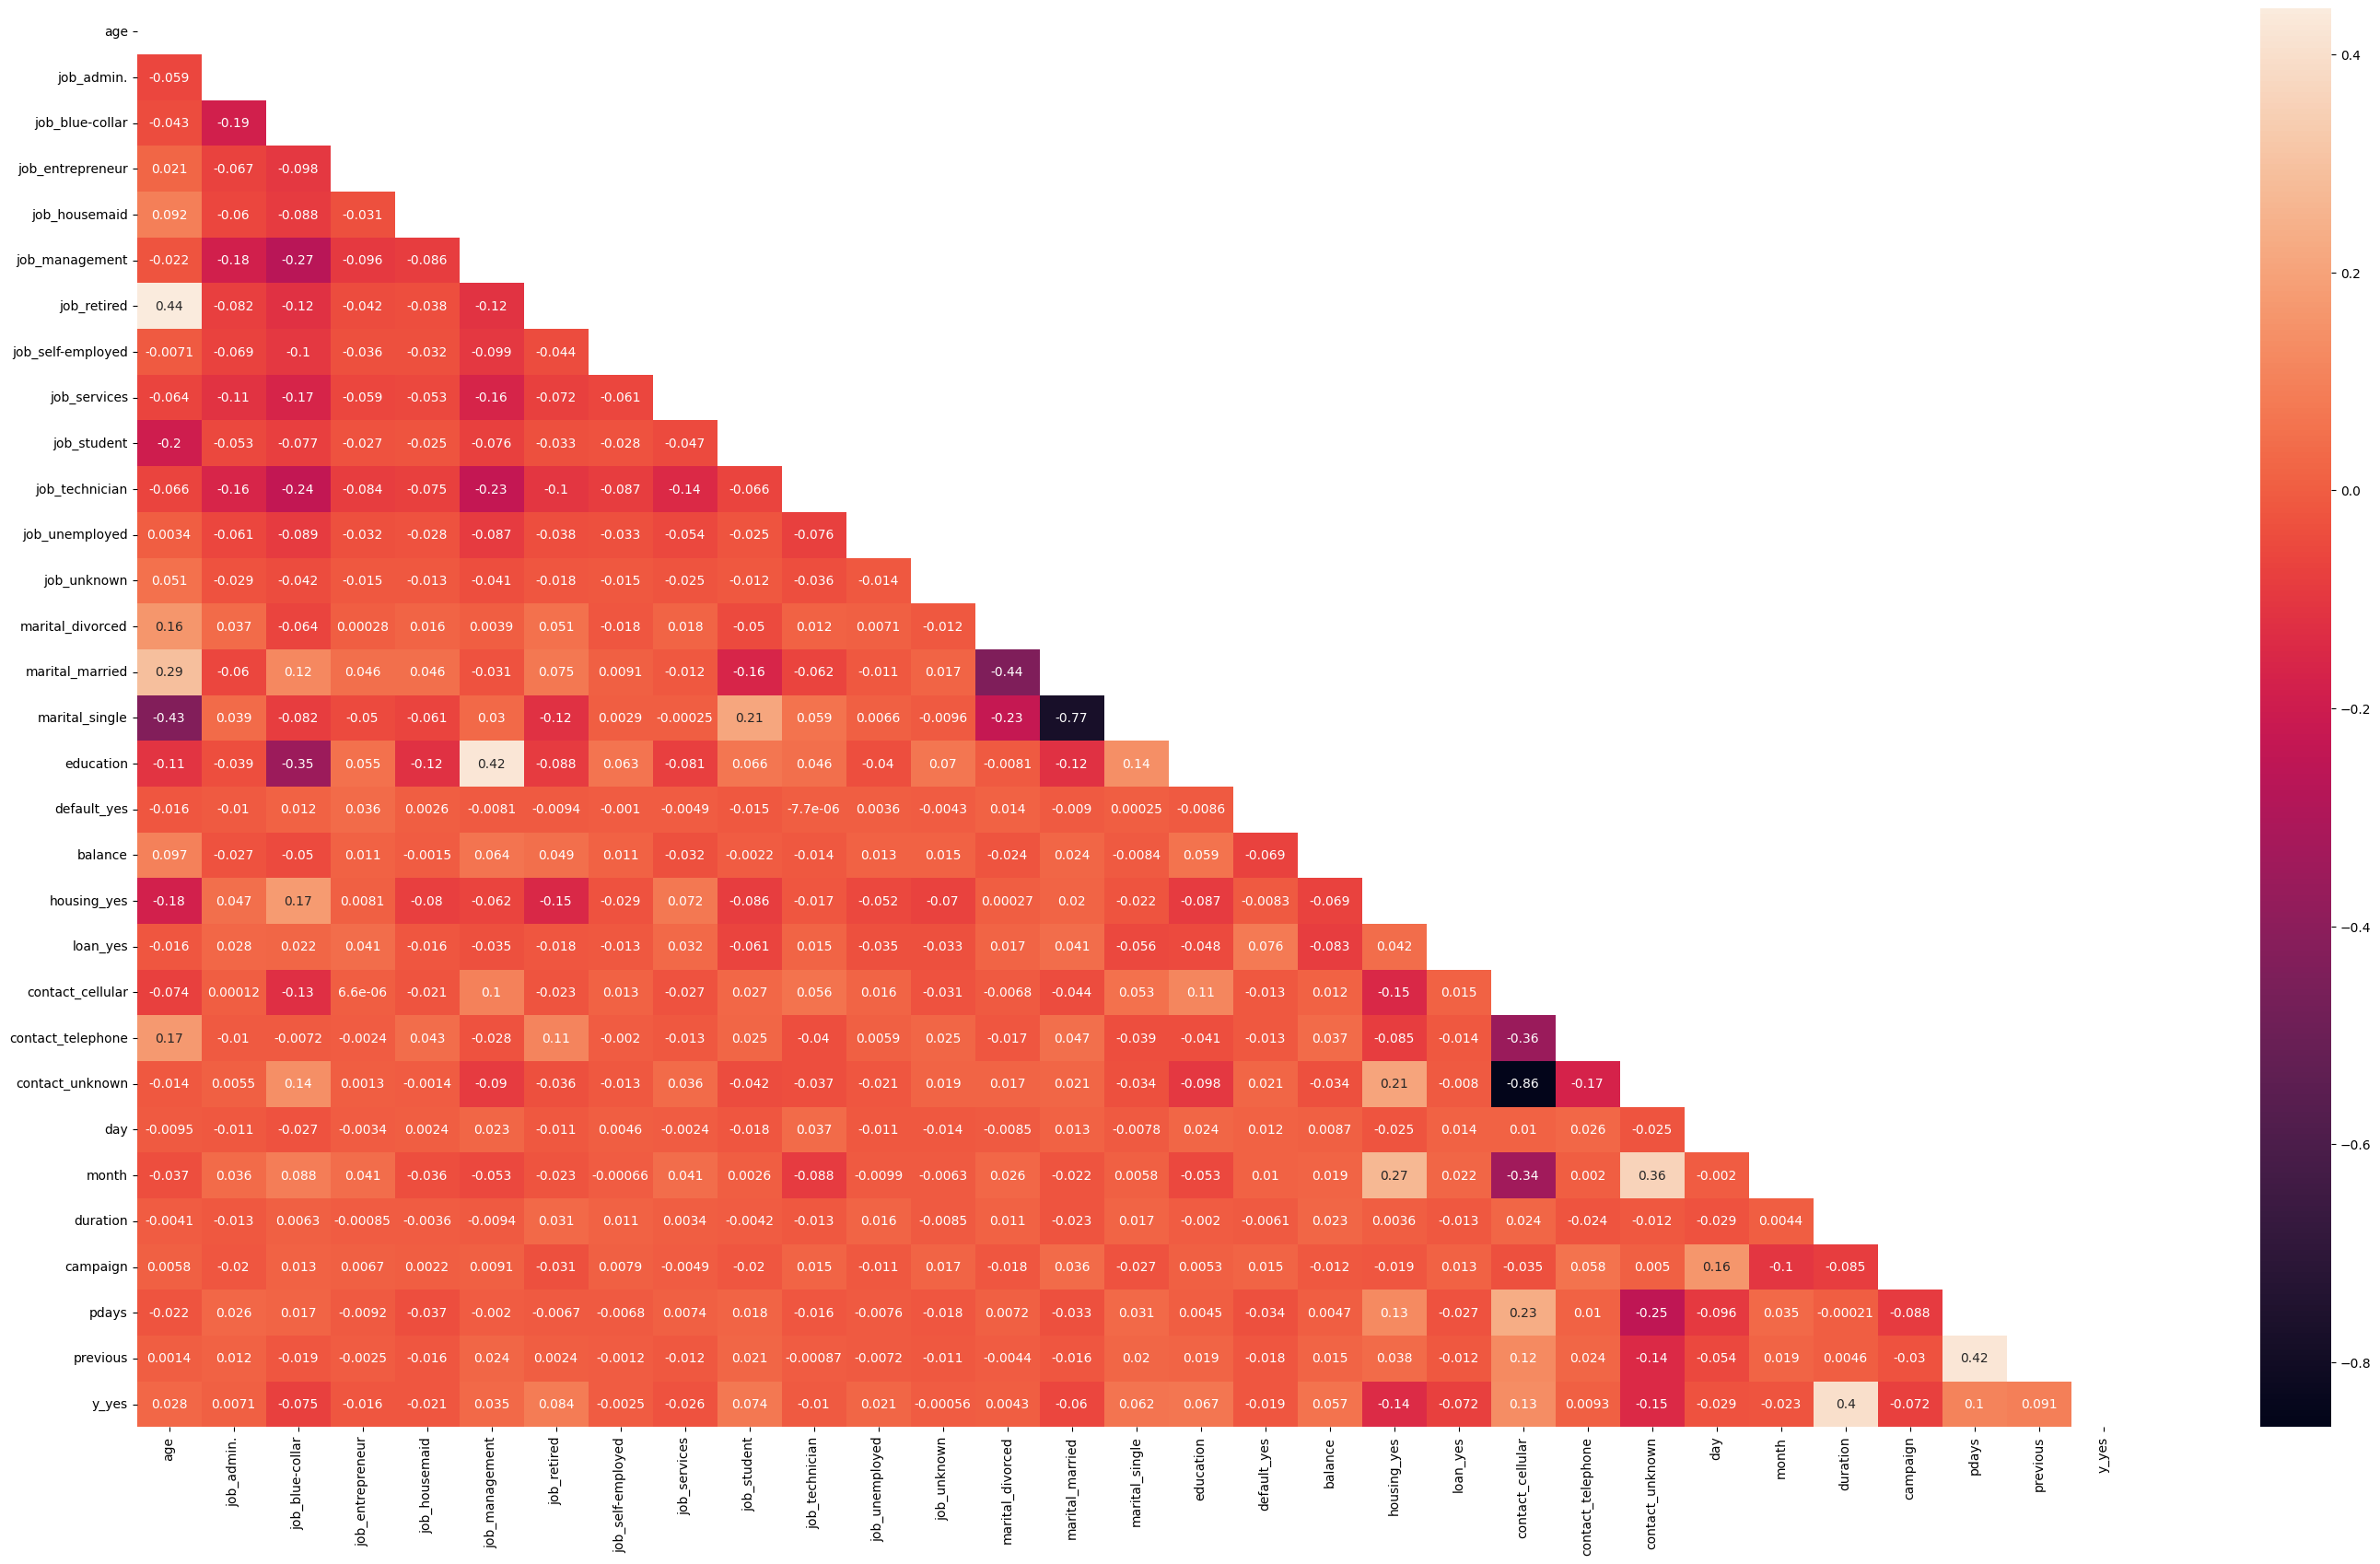

In [34]:
plt.figure(figsize=(35, 20))
# sns.heatmap(train_set_cleveland.corr(), annot=True)
sns.heatmap(train_set_e.corr(), annot=True, mask=np.triu(train_set_e.corr()))

#### plot :

#### all scatter :

In [35]:
train_set_e.shape

(28934, 31)

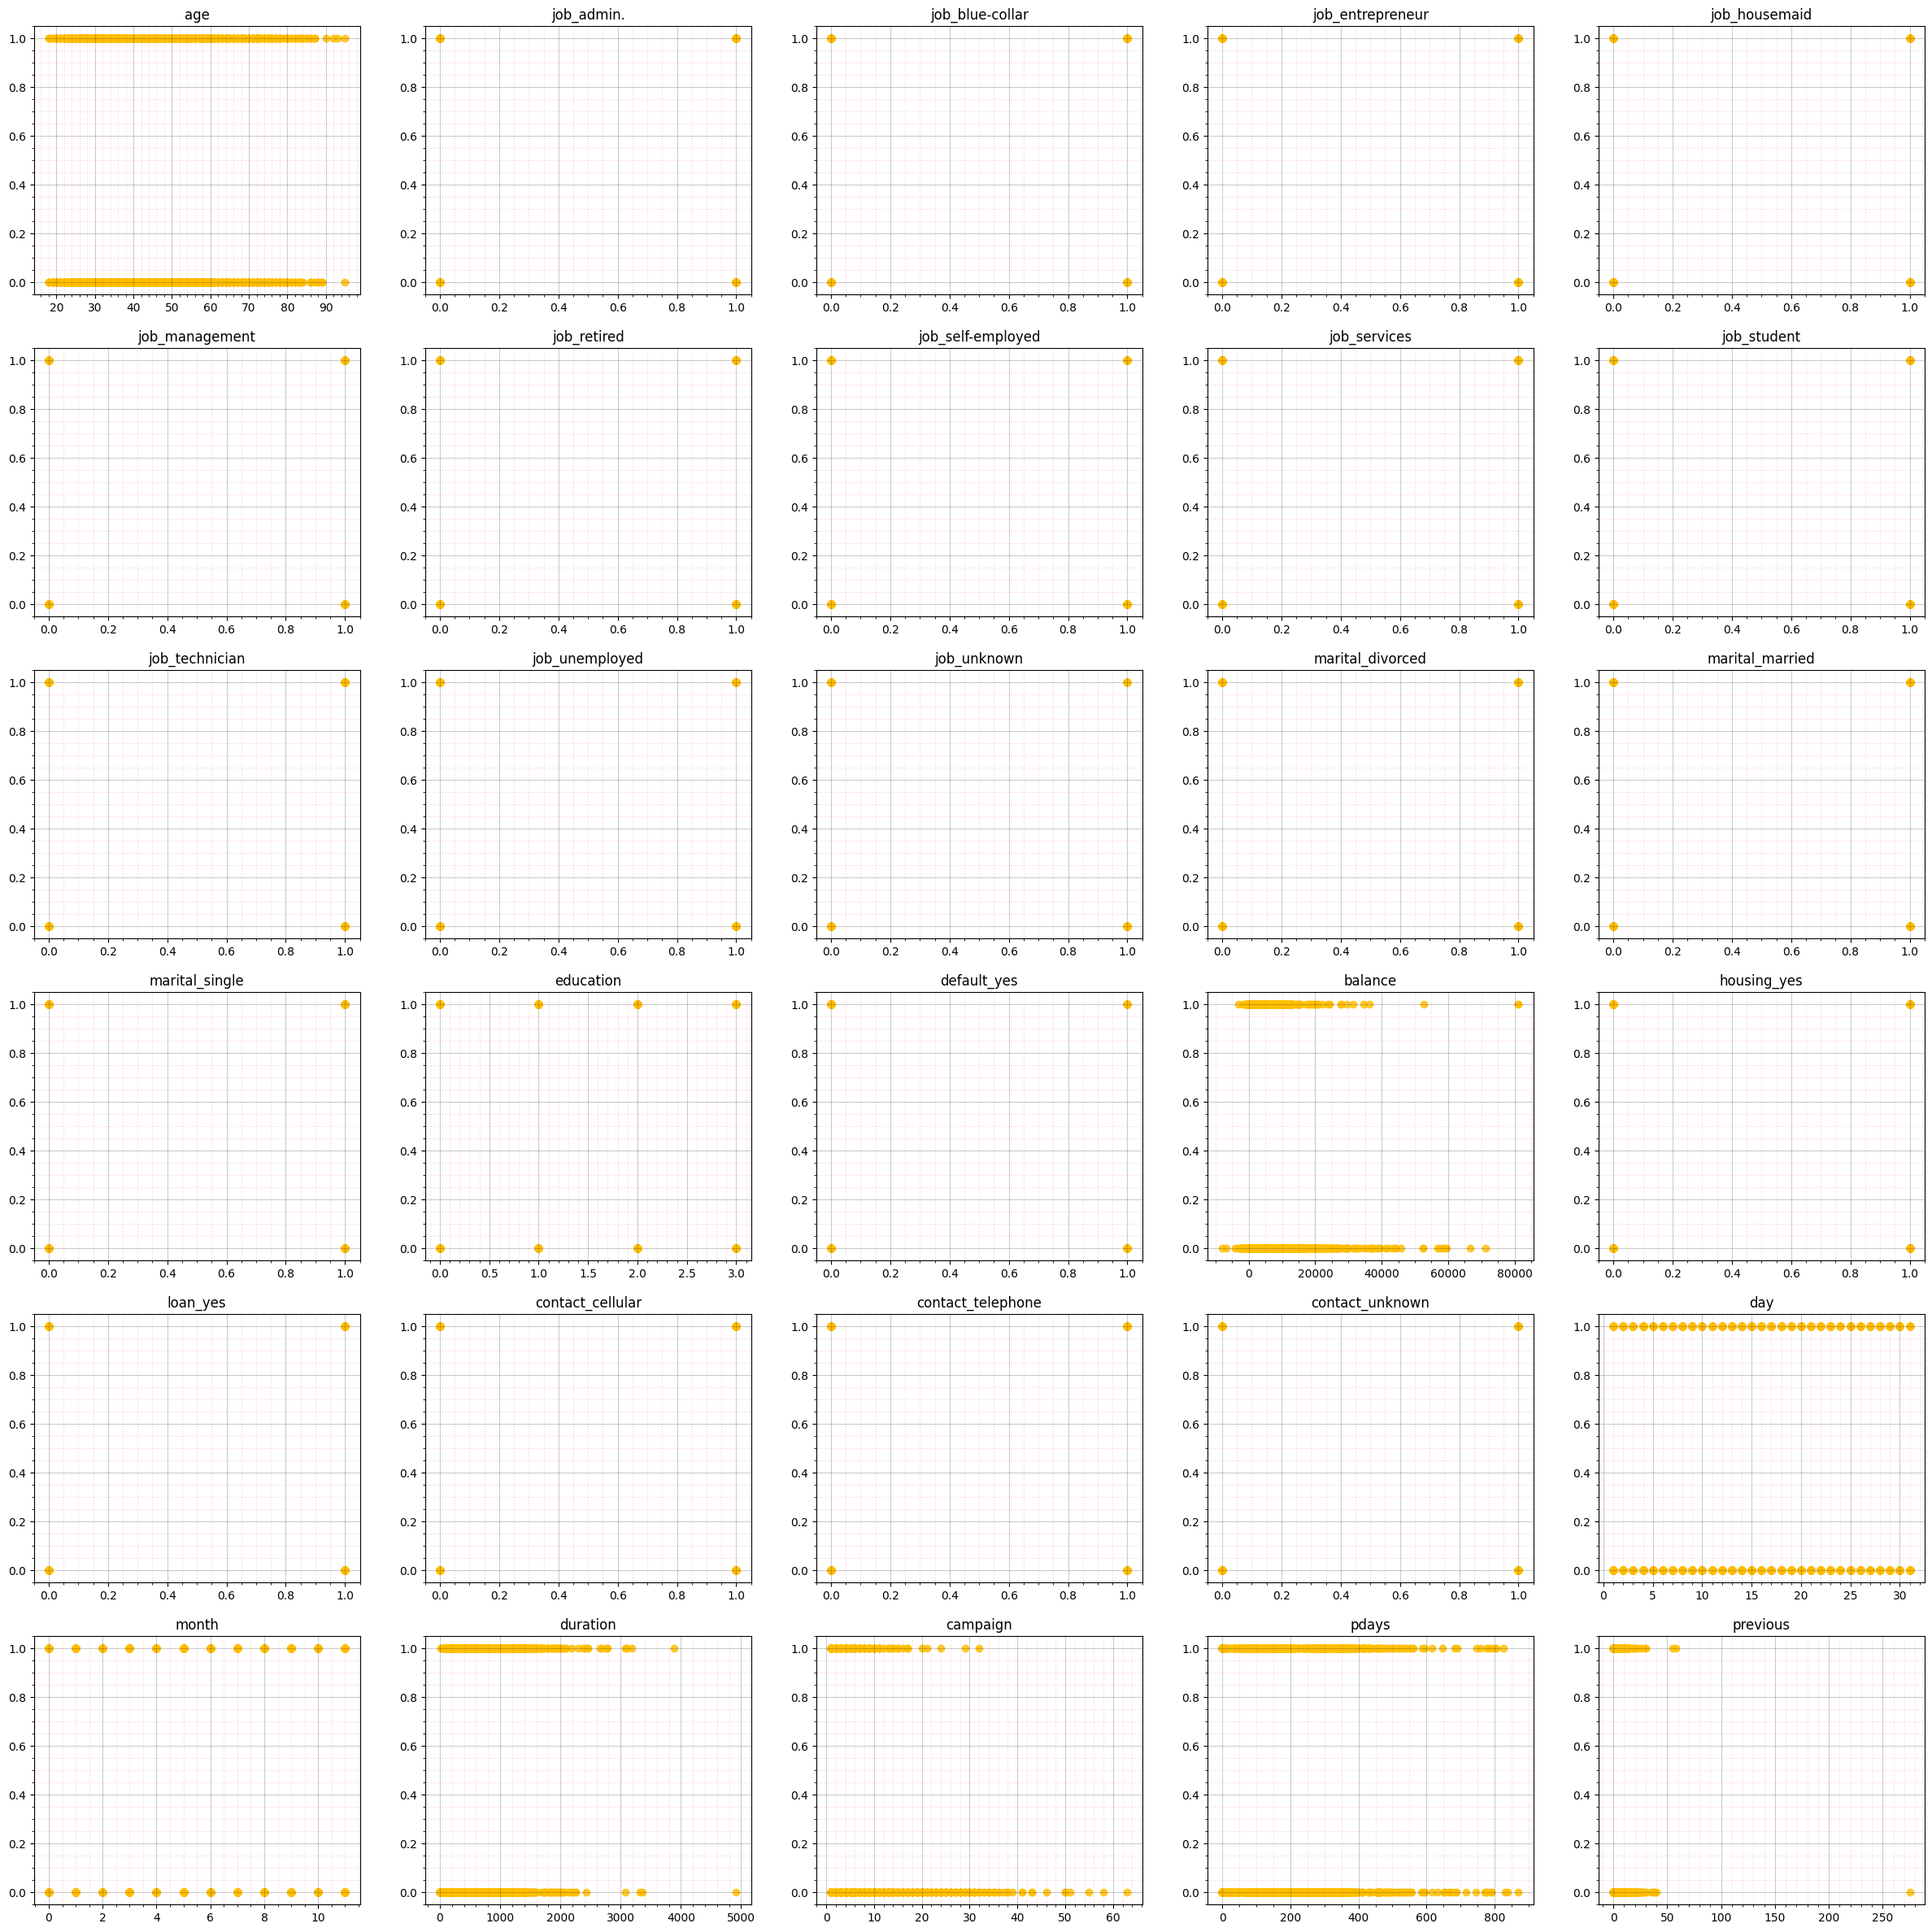

In [36]:
fig4, axs4 = plt.subplots(6, 5, figsize=(30, 30))

for i, e in enumerate([0, 5, 10, 15, 20, 25]):
    for j in range(5):
        axs4[i, j].grid(which='minor', ls = ':', c = '#FF1111', alpha = 0.2)
        axs4[i, j].grid(c = 'k', alpha = 0.2)
        axs4[i, j].minorticks_on()

        if (j + e) < train_set_e.shape[1] :
            axs4[i, j].scatter(train_set_e.iloc[:, j+e], train_set_e.iloc[:, -1], color = '#FFBF00', alpha=0.8)
            axs4[i, j].set_title(train_set_e.columns[j+e])

#### all violinplot :

In [37]:
train_set_e.columns

Index(['age', 'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_divorced', 'marital_married', 'marital_single',
       'education', 'default_yes', 'balance', 'housing_yes', 'loan_yes',
       'contact_cellular', 'contact_telephone', 'contact_unknown', 'day',
       'month', 'duration', 'campaign', 'pdays', 'previous', 'y_yes'],
      dtype='object')

In [38]:
col = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
pd.unique(encoder.fit_transform(train_set[col[3]]))

array([0, 1])

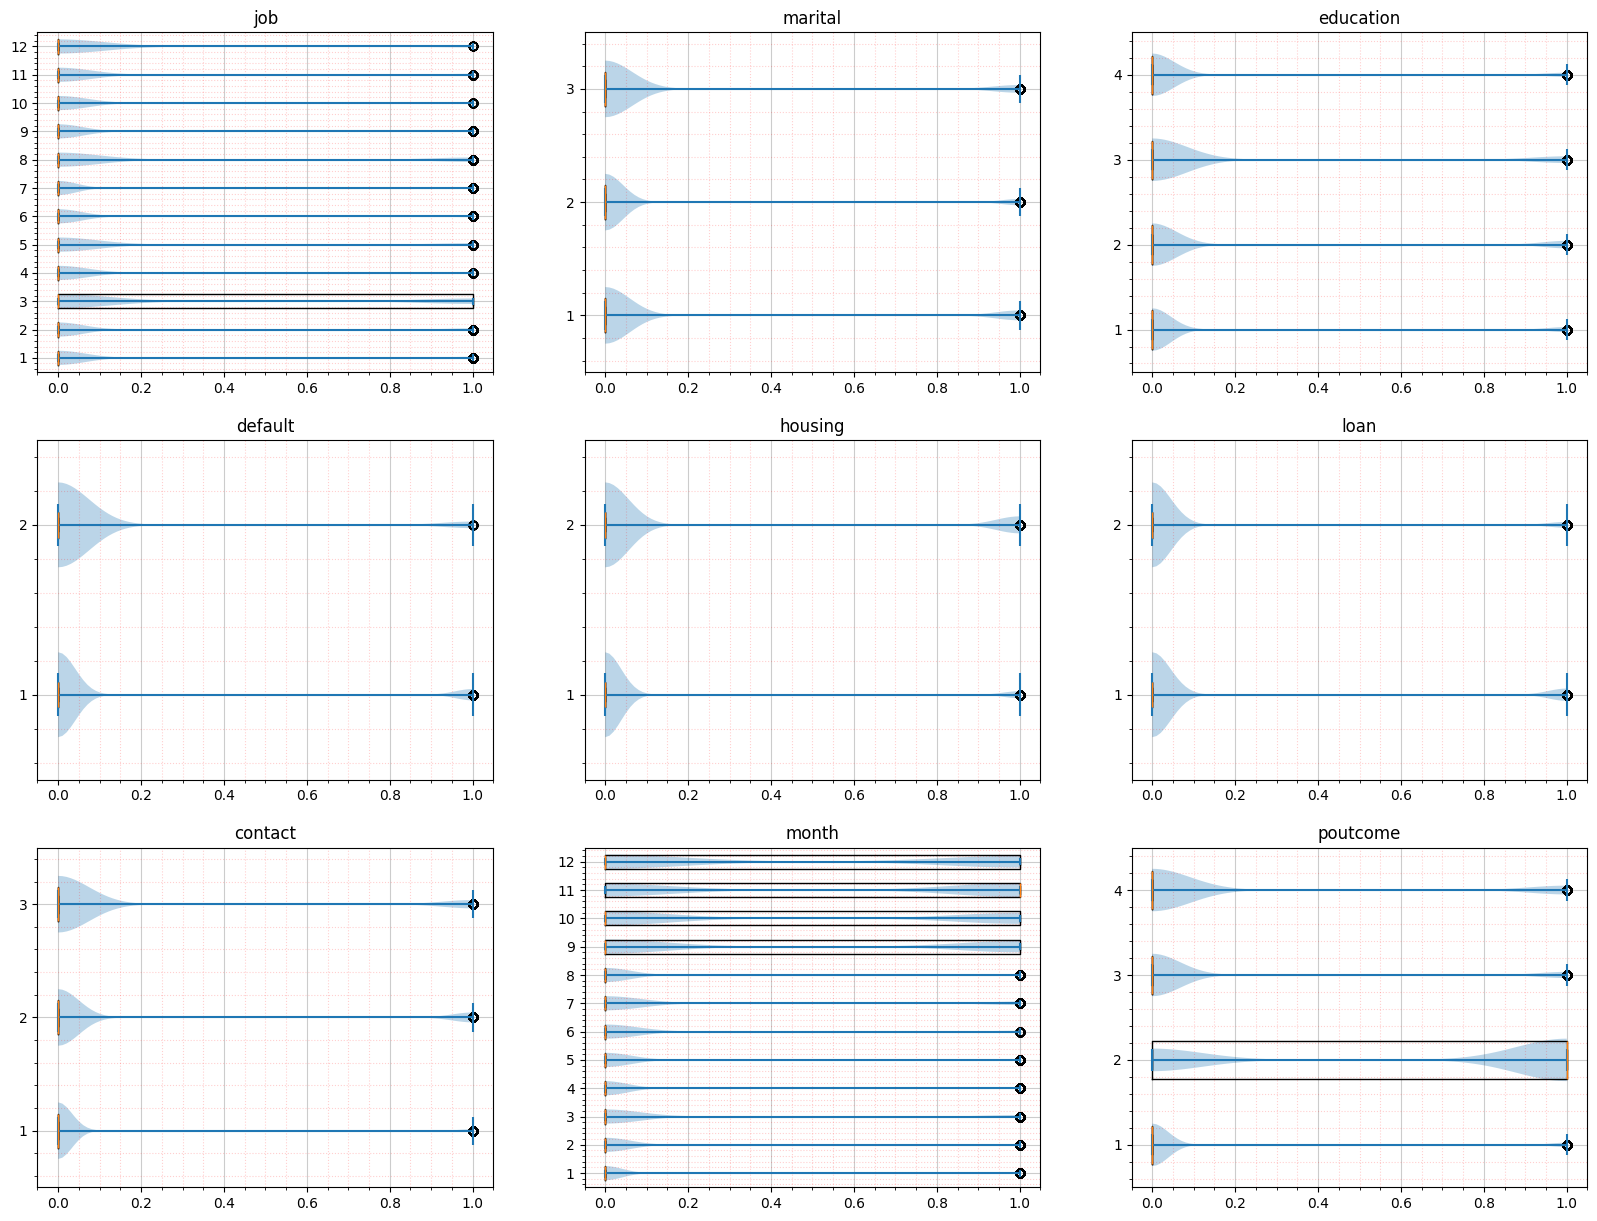

In [39]:
fig5, axs5 = plt.subplots(3, 3, figsize=(20, 15))

for i, e in enumerate([0, 3, 6]):
    for j in range(3):
        axs5[i, j].grid(which='minor', ls = ':', c = '#FF1111', alpha = 0.2)
        axs5[i, j].grid(c = 'k', alpha = 0.2)
        axs5[i, j].minorticks_on()

        if (j + e) < len(col) :
            axs5[i, j].boxplot([encoder.fit_transform(train_set.y)[encoder.fit_transform(train_set[col[j + e]]) == var] for var in pd.unique(encoder.fit_transform(train_set[col[j + e]]))], vert=False)
            axs5[i, j].violinplot([encoder.fit_transform(train_set.y)[encoder.fit_transform(train_set[col[j + e]]) == var] for var in pd.unique(encoder.fit_transform(train_set[col[j + e]]))], vert=False)
            axs5[i, j].set_title(col[j+e])

In [40]:
train_numeric.shape

(28934, 7)

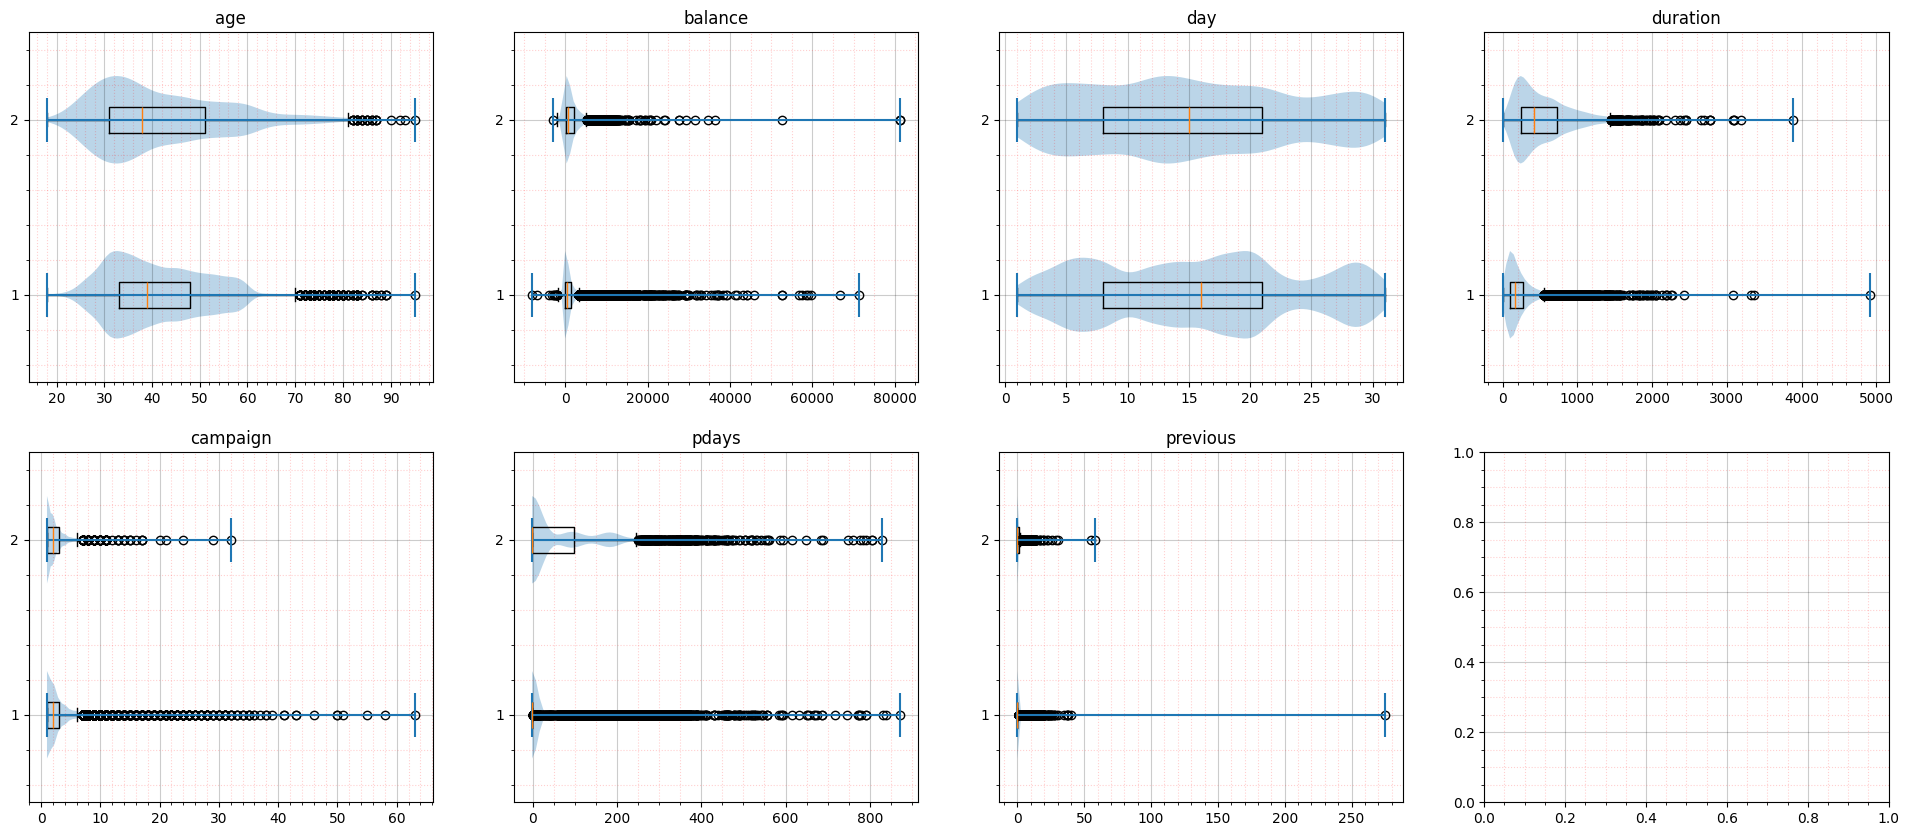

In [41]:
fig5, axs5 = plt.subplots(2, 4, figsize=(24, 10))

for i, e in enumerate([0, 4]):
    for j in range(4):
        axs5[i, j].grid(which='minor', ls = ':', c = '#FF1111', alpha = 0.2)
        axs5[i, j].grid(c = 'k', alpha = 0.2)
        axs5[i, j].minorticks_on()

        if (j + e) < train_numeric.shape[1] :
            axs5[i, j].boxplot([train_numeric.iloc[:, j+e][np.where(train_set.y =='no', 0, 1) == var] for var in pd.unique(np.where(train_set.y =='no', 0, 1))], vert=False)
            axs5[i, j].violinplot([train_numeric.iloc[:, j+e][np.where(train_set.y =='no', 0, 1) == var] for var in pd.unique(np.where(train_set.y =='no', 0, 1))], vert=False)
            axs5[i, j].set_title(train_numeric.columns[j+e])

### Multi variable :

In [42]:
train_set_e.shape

(28934, 31)

In [43]:
train_set_e.columns

Index(['age', 'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_divorced', 'marital_married', 'marital_single',
       'education', 'default_yes', 'balance', 'housing_yes', 'loan_yes',
       'contact_cellular', 'contact_telephone', 'contact_unknown', 'day',
       'month', 'duration', 'campaign', 'pdays', 'previous', 'y_yes'],
      dtype='object')

In [44]:
train_set_e.columns[28]

'pdays'

Text(0.5, 1.0, 'default_yes')

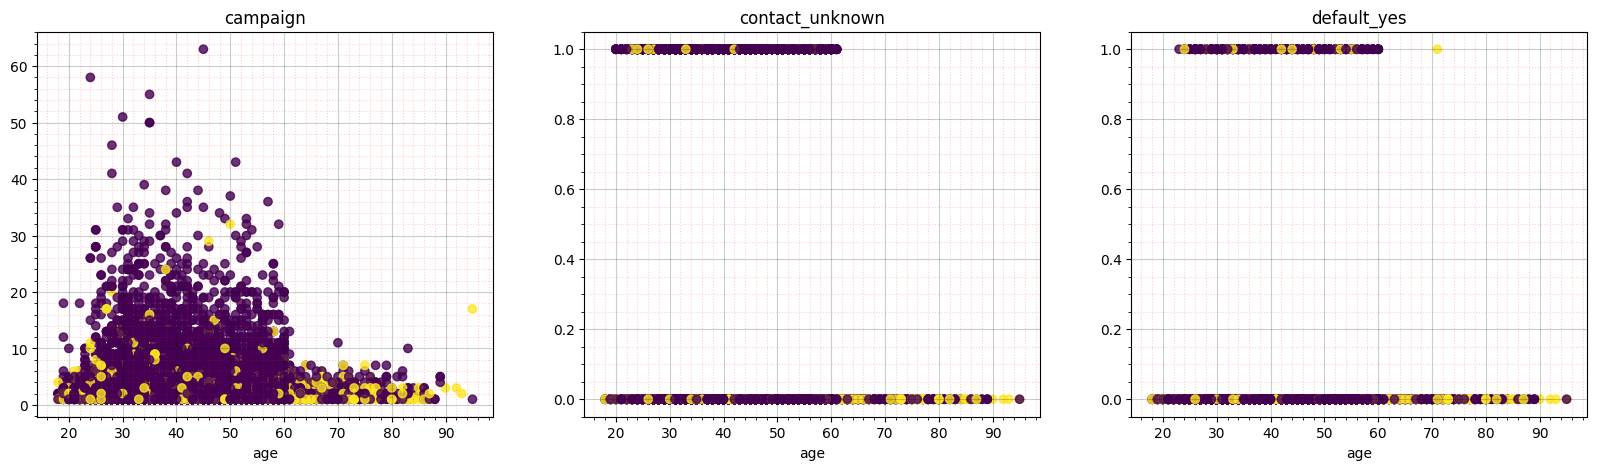

In [45]:
# age 

fig4, axs4 = plt.subplots(1, 3, figsize=(20, 5))

for j in range(3):
    axs4[j].grid(which='minor', ls = ':', c = '#FF1111', alpha = 0.2)
    axs4[j].grid(c = 'k', alpha = 0.2)
    axs4[j].minorticks_on()
    axs4[j].set_xlabel('age')

axs4[0].scatter(train_set_e.age , train_set_e.campaign, c = train_set_e.y_yes, alpha=0.8)
axs4[0].set_title('campaign')

axs4[1].scatter(train_set_e.age , train_set_e.contact_unknown, c = train_set_e.y_yes, alpha=0.8)
axs4[1].set_title('contact_unknown')

axs4[2].scatter(train_set_e.age , train_set_e.default_yes, c = train_set_e.y_yes, alpha=0.8)
axs4[2].set_title('default_yes')

Text(0.5, 0, 'job_unknown')

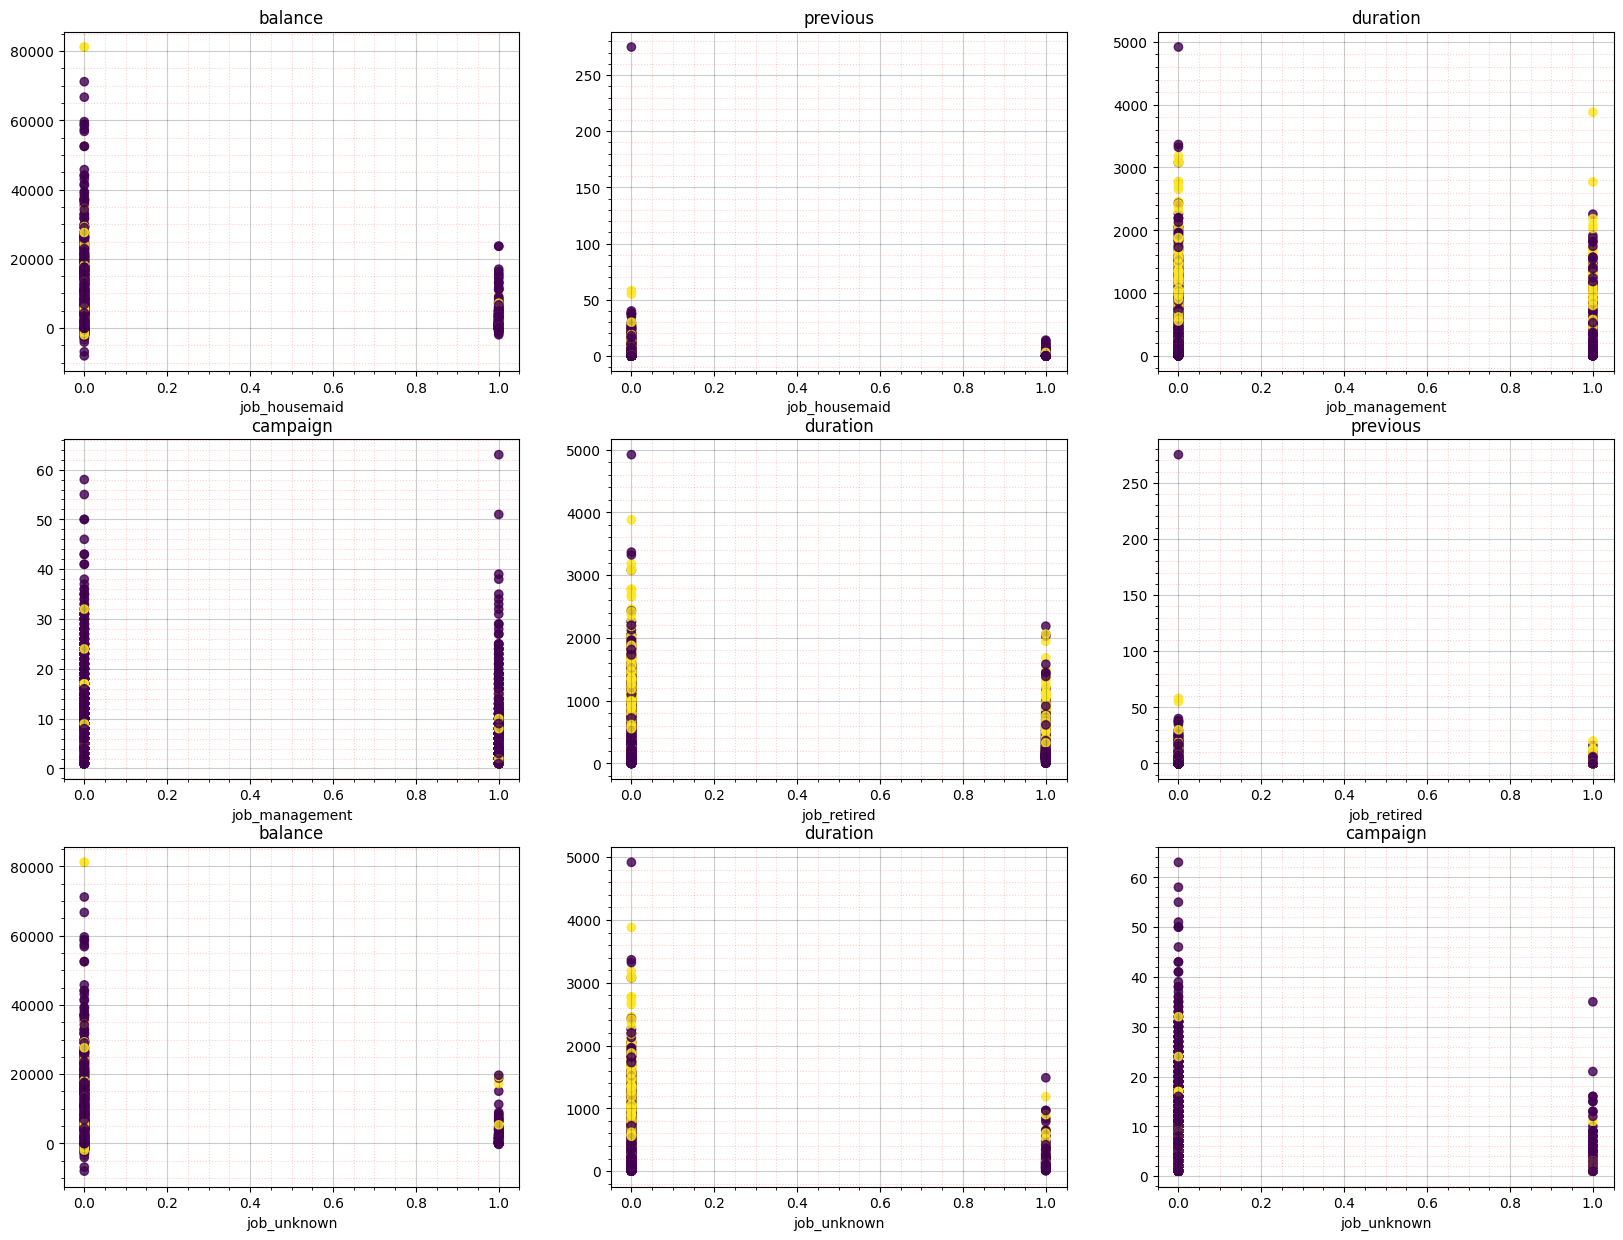

In [46]:
# job

fig4, axs4 = plt.subplots(3, 3, figsize=(20, 15))
for i in range(3):
    for j in range(3):
        axs4[i, j].grid(which='minor', ls = ':', c = '#FF1111', alpha = 0.2)
        axs4[i, j].grid(c = 'k', alpha = 0.2)
        axs4[i, j].minorticks_on()


# job_housemaid 
axs4[0, 0].scatter(train_set_e.job_housemaid , train_set_e.balance, c = train_set_e.y_yes, alpha=0.8)
axs4[0, 0].set_title('balance')
axs4[0, 0].set_xlabel('job_housemaid')

axs4[0, 1].scatter(train_set_e.job_housemaid , train_set_e.previous, c = train_set_e.y_yes, alpha=0.8)
axs4[0, 1].set_title('previous')
axs4[0, 1].set_xlabel('job_housemaid')

# job_management 
axs4[0, 2].scatter(train_set_e.job_management , train_set_e.duration, c = train_set_e.y_yes, alpha=0.8)
axs4[0, 2].set_title('duration')
axs4[0, 2].set_xlabel('job_management')

axs4[1, 0].scatter(train_set_e.job_management , train_set_e.campaign, c = train_set_e.y_yes, alpha=0.8)
axs4[1, 0].set_title('campaign')
axs4[1, 0].set_xlabel('job_management')

# job_retired
axs4[1, 1].scatter(train_set_e.job_retired , train_set_e.duration, c = train_set_e.y_yes, alpha=0.8)
axs4[1, 1].set_title('duration')
axs4[1, 1].set_xlabel('job_retired')

axs4[1, 2].scatter(train_set_e.job_retired , train_set_e.previous, c = train_set_e.y_yes, alpha=0.8)
axs4[1, 2].set_title('previous')
axs4[1, 2].set_xlabel('job_retired')

# job_unknown 
axs4[2, 0].scatter(train_set_e.job_unknown , train_set_e.balance, c = train_set_e.y_yes, alpha=0.8)
axs4[2, 0].set_title('balance')
axs4[2, 0].set_xlabel('job_unknown')

axs4[2, 1].scatter(train_set_e.job_unknown , train_set_e.duration, c = train_set_e.y_yes, alpha=0.8)
axs4[2, 1].set_title('duration')
axs4[2, 1].set_xlabel('job_unknown')

axs4[2, 2].scatter(train_set_e.job_unknown , train_set_e.campaign, c = train_set_e.y_yes, alpha=0.8)
axs4[2, 2].set_title('campaign')
axs4[2, 2].set_xlabel('job_unknown')

Text(0.5, 1.0, 'campaign')

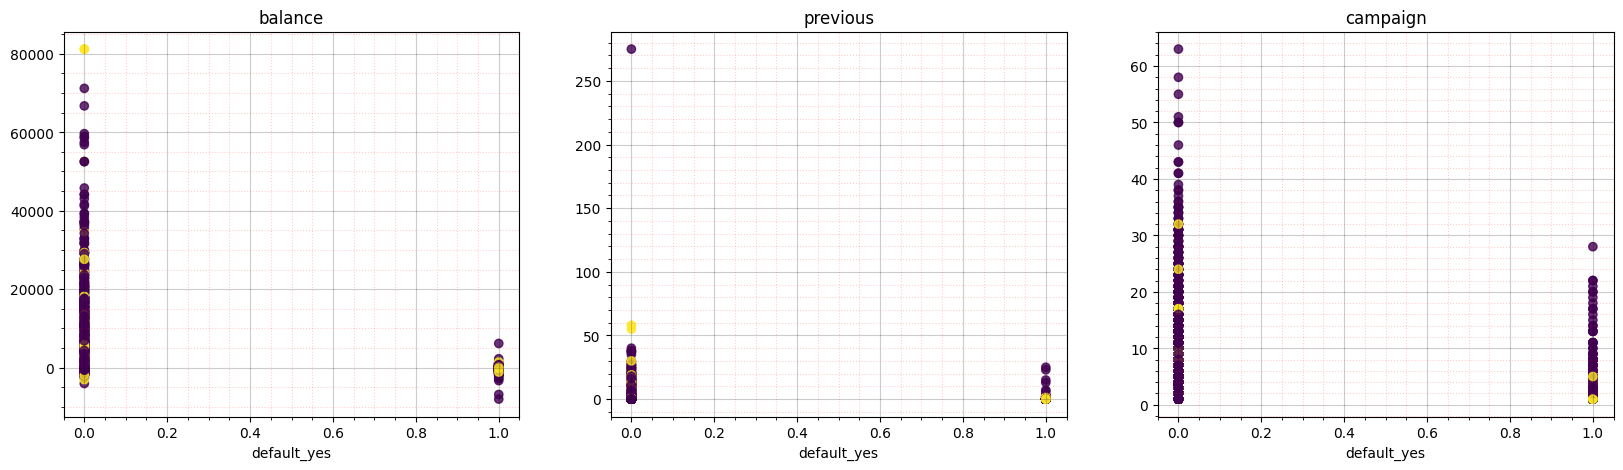

In [47]:
# default_yes 

fig4, axs4 = plt.subplots(1, 3, figsize=(20, 5))

for j in range(3):
    axs4[j].grid(which='minor', ls = ':', c = '#FF1111', alpha = 0.2)
    axs4[j].grid(c = 'k', alpha = 0.2)
    axs4[j].minorticks_on()
    axs4[j].set_xlabel('default_yes')

axs4[0].scatter(train_set_e.default_yes , train_set_e.balance, c = train_set_e.y_yes, alpha=0.8)
axs4[0].set_title('balance')

axs4[1].scatter(train_set_e.default_yes , train_set_e.previous, c = train_set_e.y_yes, alpha=0.8)
axs4[1].set_title('previous')

axs4[2].scatter(train_set_e.default_yes , train_set_e.campaign, c = train_set_e.y_yes, alpha=0.8)
axs4[2].set_title('campaign')

Text(0.5, 1.0, 'duration')

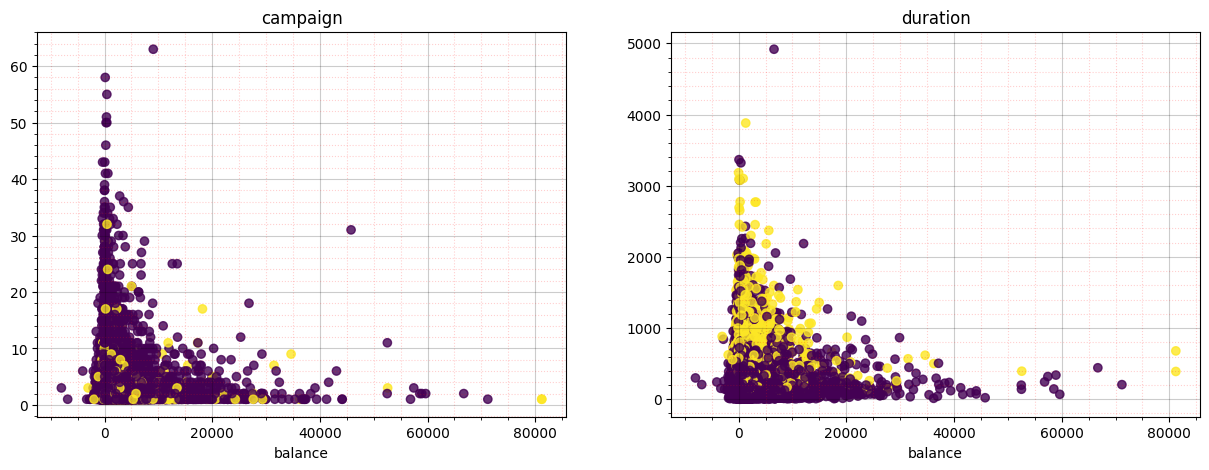

In [48]:
# balance 

fig4, axs4 = plt.subplots(1, 2, figsize=(15, 5))

for j in range(2):
    axs4[j].grid(which='minor', ls = ':', c = '#FF1111', alpha = 0.2)
    axs4[j].grid(c = 'k', alpha = 0.2)
    axs4[j].minorticks_on()
    axs4[j].set_xlabel('balance')

axs4[0].scatter(train_set_e.balance , train_set_e.campaign, c = train_set_e.y_yes, alpha=0.8)
axs4[0].set_title('campaign')

axs4[1].scatter(train_set_e.balance , train_set_e.duration, c = train_set_e.y_yes, alpha=0.8)
axs4[1].set_title('duration')

Text(0.5, 1.0, 'duration')

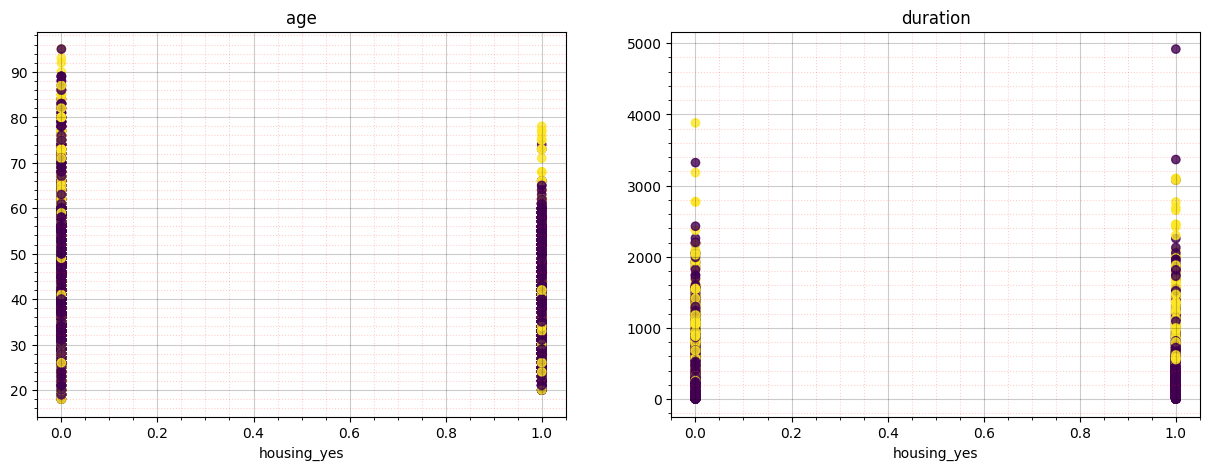

In [49]:
# housing_yes 

fig4, axs4 = plt.subplots(1, 2, figsize=(15, 5))

for j in range(2):
    axs4[j].grid(which='minor', ls = ':', c = '#FF1111', alpha = 0.2)
    axs4[j].grid(c = 'k', alpha = 0.2)
    axs4[j].minorticks_on()
    axs4[j].set_xlabel('housing_yes')

axs4[0].scatter(train_set_e.housing_yes , train_set_e.age, c = train_set_e.y_yes, alpha=0.8)
axs4[0].set_title('age')

axs4[1].scatter(train_set_e.housing_yes , train_set_e.duration, c = train_set_e.y_yes, alpha=0.8)
axs4[1].set_title('duration')

Text(0.5, 1.0, 'duration')

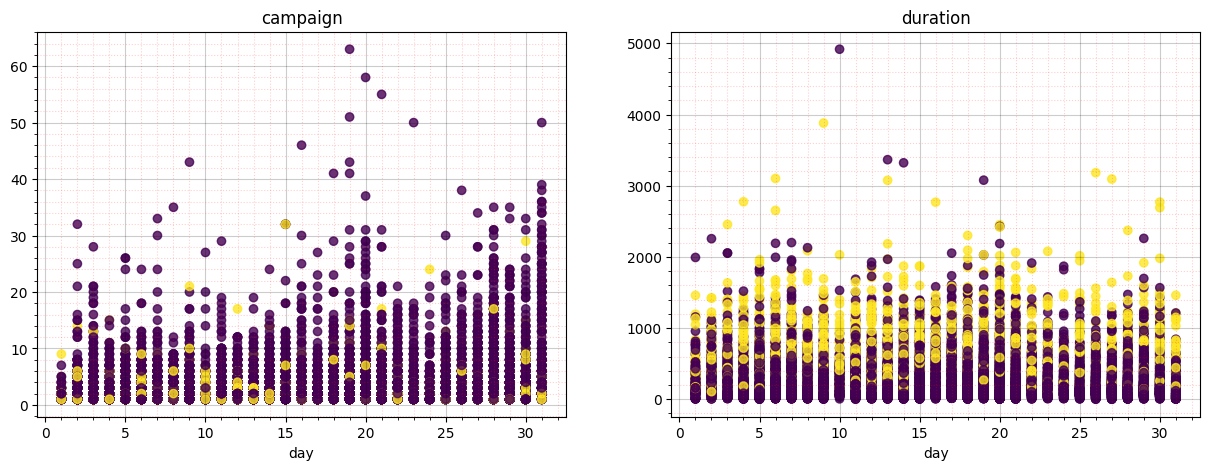

In [50]:
# day 

fig4, axs4 = plt.subplots(1, 2, figsize=(15, 5))

for j in range(2):
    axs4[j].grid(which='minor', ls = ':', c = '#FF1111', alpha = 0.2)
    axs4[j].grid(c = 'k', alpha = 0.2)
    axs4[j].minorticks_on()
    axs4[j].set_xlabel('day')

axs4[0].scatter(train_set_e.day , train_set_e.campaign, c = train_set_e.y_yes, alpha=0.8)
axs4[0].set_title('campaign')

axs4[1].scatter(train_set_e.day , train_set_e.duration, c = train_set_e.y_yes, alpha=0.8)
axs4[1].set_title('duration')

Text(0.5, 0, 'duration')

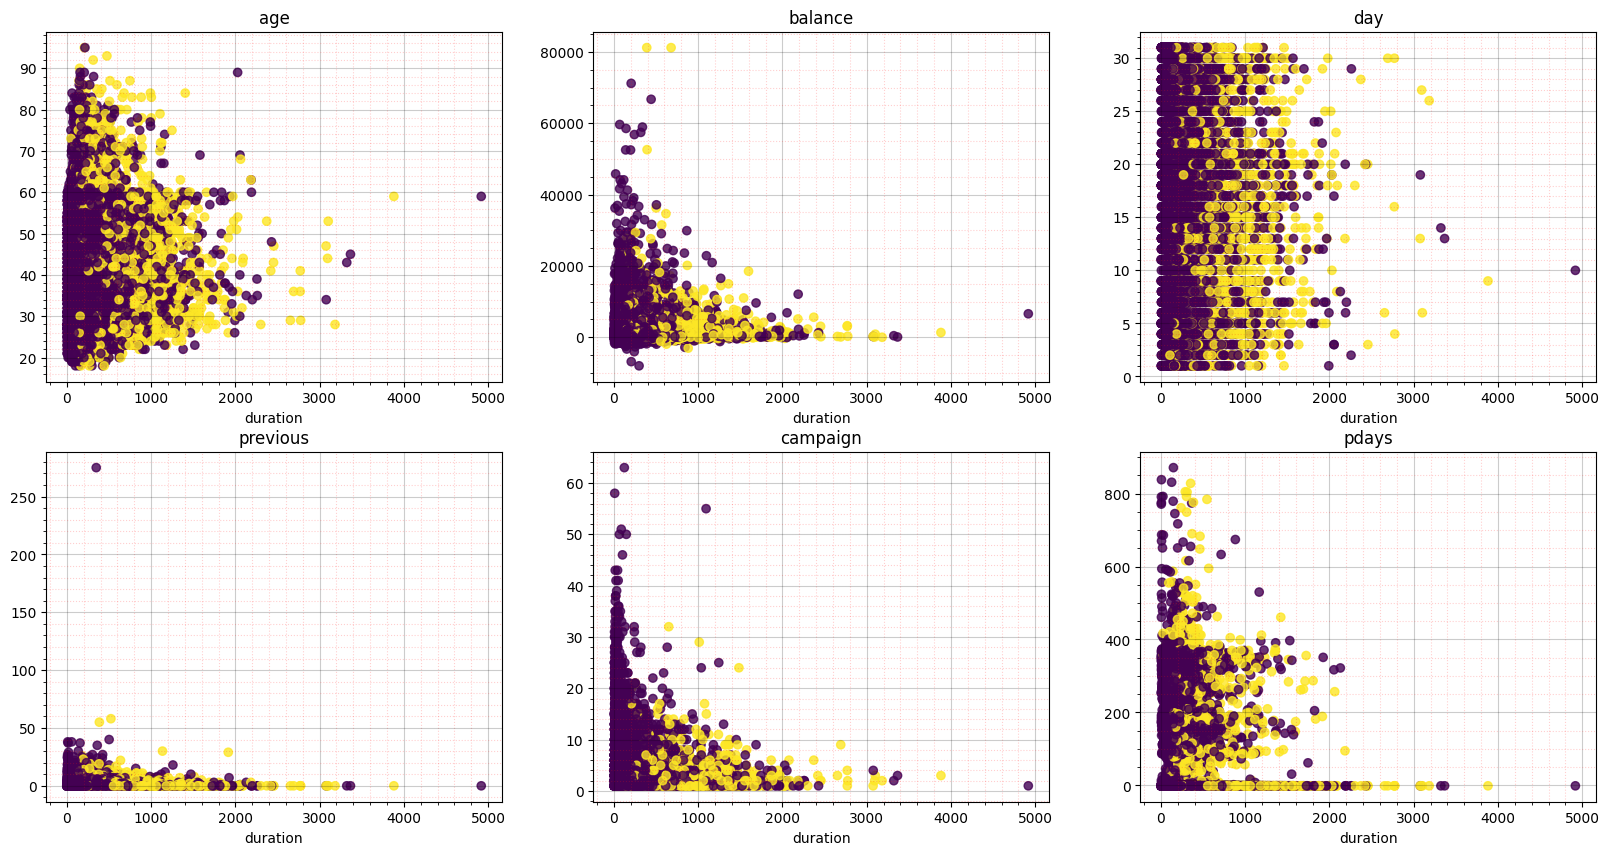

In [51]:
# duration

fig4, axs4 = plt.subplots(2, 3, figsize=(20, 10))
for i in range(2):
    for j in range(3):
        axs4[i, j].grid(which='minor', ls = ':', c = '#FF1111', alpha = 0.2)
        axs4[i, j].grid(c = 'k', alpha = 0.2)
        axs4[i, j].minorticks_on()


axs4[0, 0].scatter(train_set_e.duration , train_set_e.age, c = train_set_e.y_yes, alpha=0.8)
axs4[0, 0].set_title('age')
axs4[0, 0].set_xlabel('duration')

axs4[0, 1].scatter(train_set_e.duration , train_set_e.balance, c = train_set_e.y_yes, alpha=0.8)
axs4[0, 1].set_title('balance')
axs4[0, 1].set_xlabel('duration')


axs4[0, 2].scatter(train_set_e.duration , train_set_e.day, c = train_set_e.y_yes, alpha=0.8)
axs4[0, 2].set_title('day')
axs4[0, 2].set_xlabel('duration')

axs4[1, 0].scatter(train_set_e.duration , train_set_e.previous, c = train_set_e.y_yes, alpha=0.8)
axs4[1, 0].set_title('previous')
axs4[1, 0].set_xlabel('duration')


axs4[1, 1].scatter(train_set_e.duration , train_set_e.campaign, c = train_set_e.y_yes, alpha=0.8)
axs4[1, 1].set_title('campaign')
axs4[1, 1].set_xlabel('duration')

axs4[1, 2].scatter(train_set_e.duration , train_set_e.pdays, c = train_set_e.y_yes, alpha=0.8)
axs4[1, 2].set_title('pdays')
axs4[1, 2].set_xlabel('duration')

Text(0.5, 1.0, 'previous')

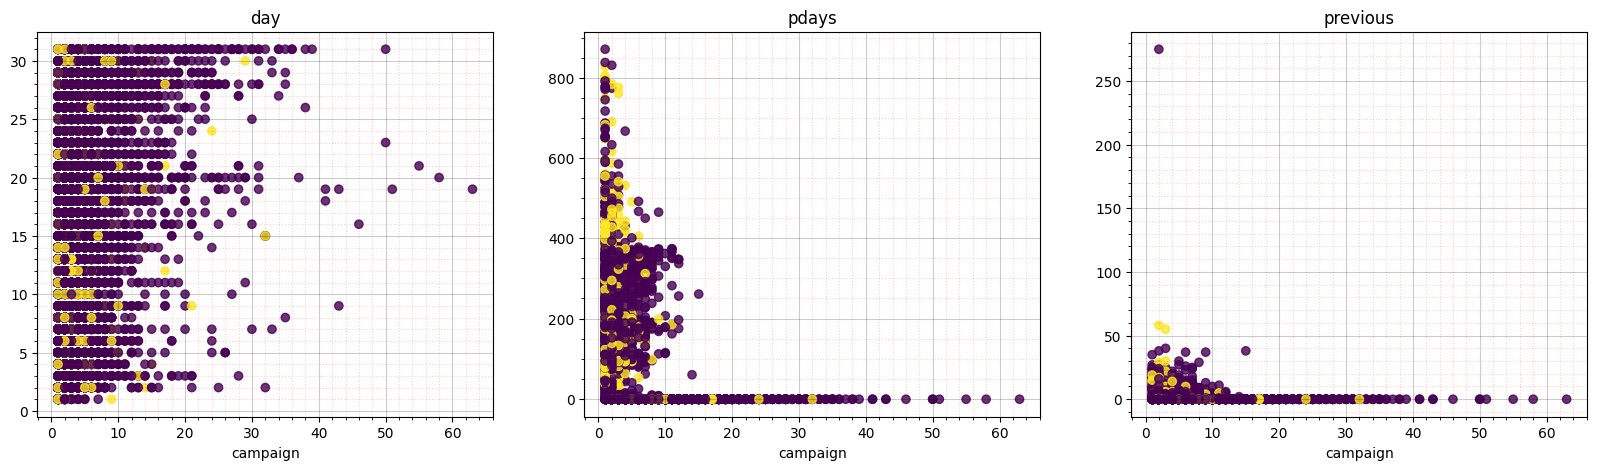

In [52]:
# campaign 

fig4, axs4 = plt.subplots(1, 3, figsize=(20, 5))

for j in range(3):
    axs4[j].grid(which='minor', ls = ':', c = '#FF1111', alpha = 0.2)
    axs4[j].grid(c = 'k', alpha = 0.2)
    axs4[j].minorticks_on()
    axs4[j].set_xlabel('campaign')

axs4[0].scatter(train_set_e.campaign , train_set_e.day, c = train_set_e.y_yes, alpha=0.8)
axs4[0].set_title('day')

axs4[1].scatter(train_set_e.campaign , train_set_e.pdays, c = train_set_e.y_yes, alpha=0.8)
axs4[1].set_title('pdays')

axs4[2].scatter(train_set_e.campaign , train_set_e.previous, c = train_set_e.y_yes, alpha=0.8)
axs4[2].set_title('previous')

Text(0.5, 1.0, 'duration')

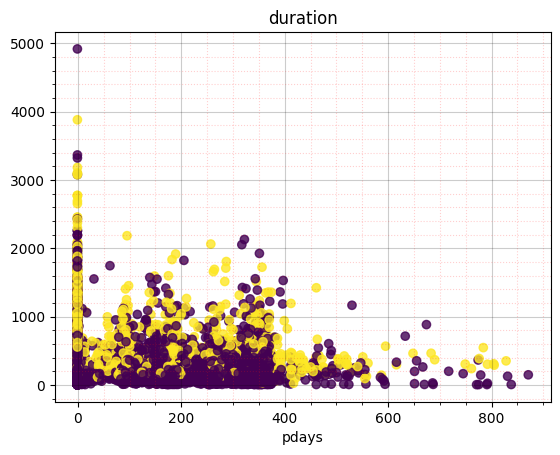

In [53]:
# pdays

plt.grid(which='minor', ls = ':', c = '#FF1111', alpha = 0.2)
plt.grid(c = 'k', alpha = 0.2)
plt.minorticks_on()
plt.xlabel('pdays')

plt.scatter(train_set_e.pdays , train_set_e.duration, c = train_set_e.y_yes, alpha=0.8)
plt.title('duration')

Text(0.5, 0, 'duration')

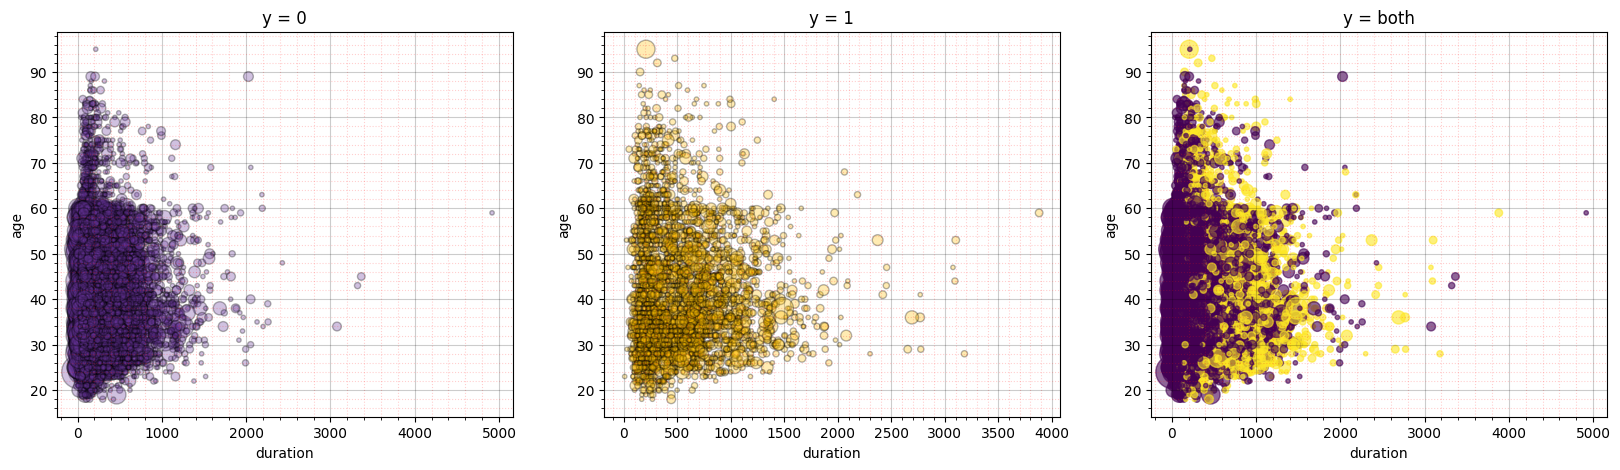

In [54]:
fig4, axs4 = plt.subplots(1, 3, figsize=(20, 5))

for j in range(3):
    axs4[j].grid(which='minor', ls = ':', c = '#FF1111', alpha = 0.2)
    axs4[j].grid(c = 'k', alpha = 0.2)
    axs4[j].minorticks_on()
    axs4[j].set_xlabel('campaign')

# plt.scatter(train_set_e.duration , train_set_e.age, c = train_set_e.y_yes, alpha=0.6, s=train_set_e.campaign*10)
axs4[0].scatter(train_set_e.duration[train_set_e.y_yes==0] , train_set_e.age[train_set_e.y_yes==0], alpha=0.3, s=train_set_e.campaign[train_set_e.y_yes==0]*10, ec='k', c='#663399')
axs4[0].set_title('y = 0')
axs4[0].set_ylabel('age')
axs4[0].set_xlabel('duration')

axs4[1].scatter(train_set_e.duration[train_set_e.y_yes==1] , train_set_e.age[train_set_e.y_yes==1], alpha=0.3, s=train_set_e.campaign[train_set_e.y_yes==1]*10, ec='k', c='#FFBF00')
axs4[1].set_title('y = 1')
axs4[1].set_ylabel('age')
axs4[1].set_xlabel('duration')

axs4[2].scatter(train_set_e.duration , train_set_e.age, c = train_set_e.y_yes, alpha=0.6, s=train_set_e.campaign*10)
# axs4[0].scatter(train_set_e.duration[train_set_e.y_yes==0] , train_set_e.age[train_set_e.y_yes==0], alpha=0.3, s=train_set_e.campaign[train_set_e.y_yes==0]*10, ec='k')
axs4[2].set_title('y = both')
axs4[2].set_ylabel('age')
axs4[2].set_xlabel('duration')

C:\Users\Ertebatat-Sahar\anaconda3\envs\python_Ai\Lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


Text(0.5, 0, 'duration')

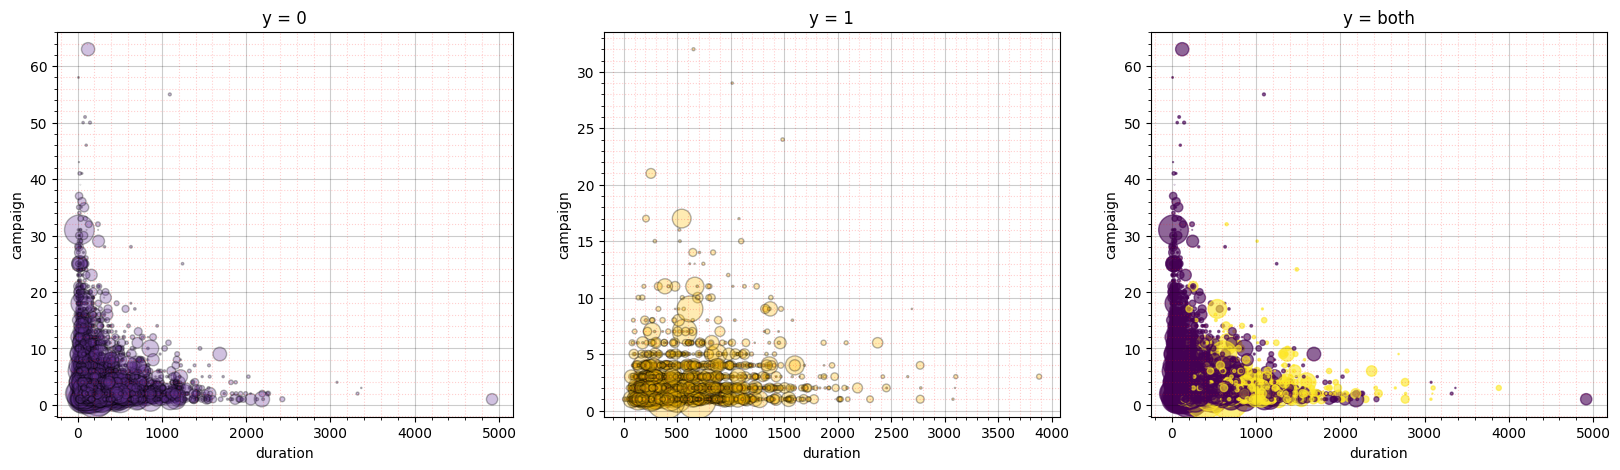

In [55]:
fig4, axs4 = plt.subplots(1, 3, figsize=(20, 5))

for j in range(3):
    axs4[j].grid(which='minor', ls = ':', c = '#FF1111', alpha = 0.2)
    axs4[j].grid(c = 'k', alpha = 0.2)
    axs4[j].minorticks_on()
    axs4[j].set_xlabel('campaign')

axs4[0].scatter(train_set_e.duration[train_set_e.y_yes==0] , train_set_e.campaign[train_set_e.y_yes==0], alpha=0.3, s=train_set_e.balance[train_set_e.y_yes==0]/100, ec='k', c='#663399')
axs4[0].set_title('y = 0')
axs4[0].set_ylabel('campaign')
axs4[0].set_xlabel('duration')

axs4[1].scatter(train_set_e.duration[train_set_e.y_yes==1] , train_set_e.campaign[train_set_e.y_yes==1], alpha=0.3, s=train_set_e.balance[train_set_e.y_yes==1]/100, ec='k', c='#FFBF00')
axs4[1].set_title('y = 1')
axs4[1].set_ylabel('campaign')
axs4[1].set_xlabel('duration')

axs4[2].scatter(train_set_e.duration , train_set_e.campaign, c = train_set_e.y_yes, alpha=0.6, s=train_set_e.balance/100)
axs4[2].set_title('y = both')
axs4[2].set_ylabel('campaign')
axs4[2].set_xlabel('duration')

## Outliers :

In [56]:
train_set.shape

(28934, 17)

In [57]:
train_set.iloc[:, 5].dtype == 'category'

False

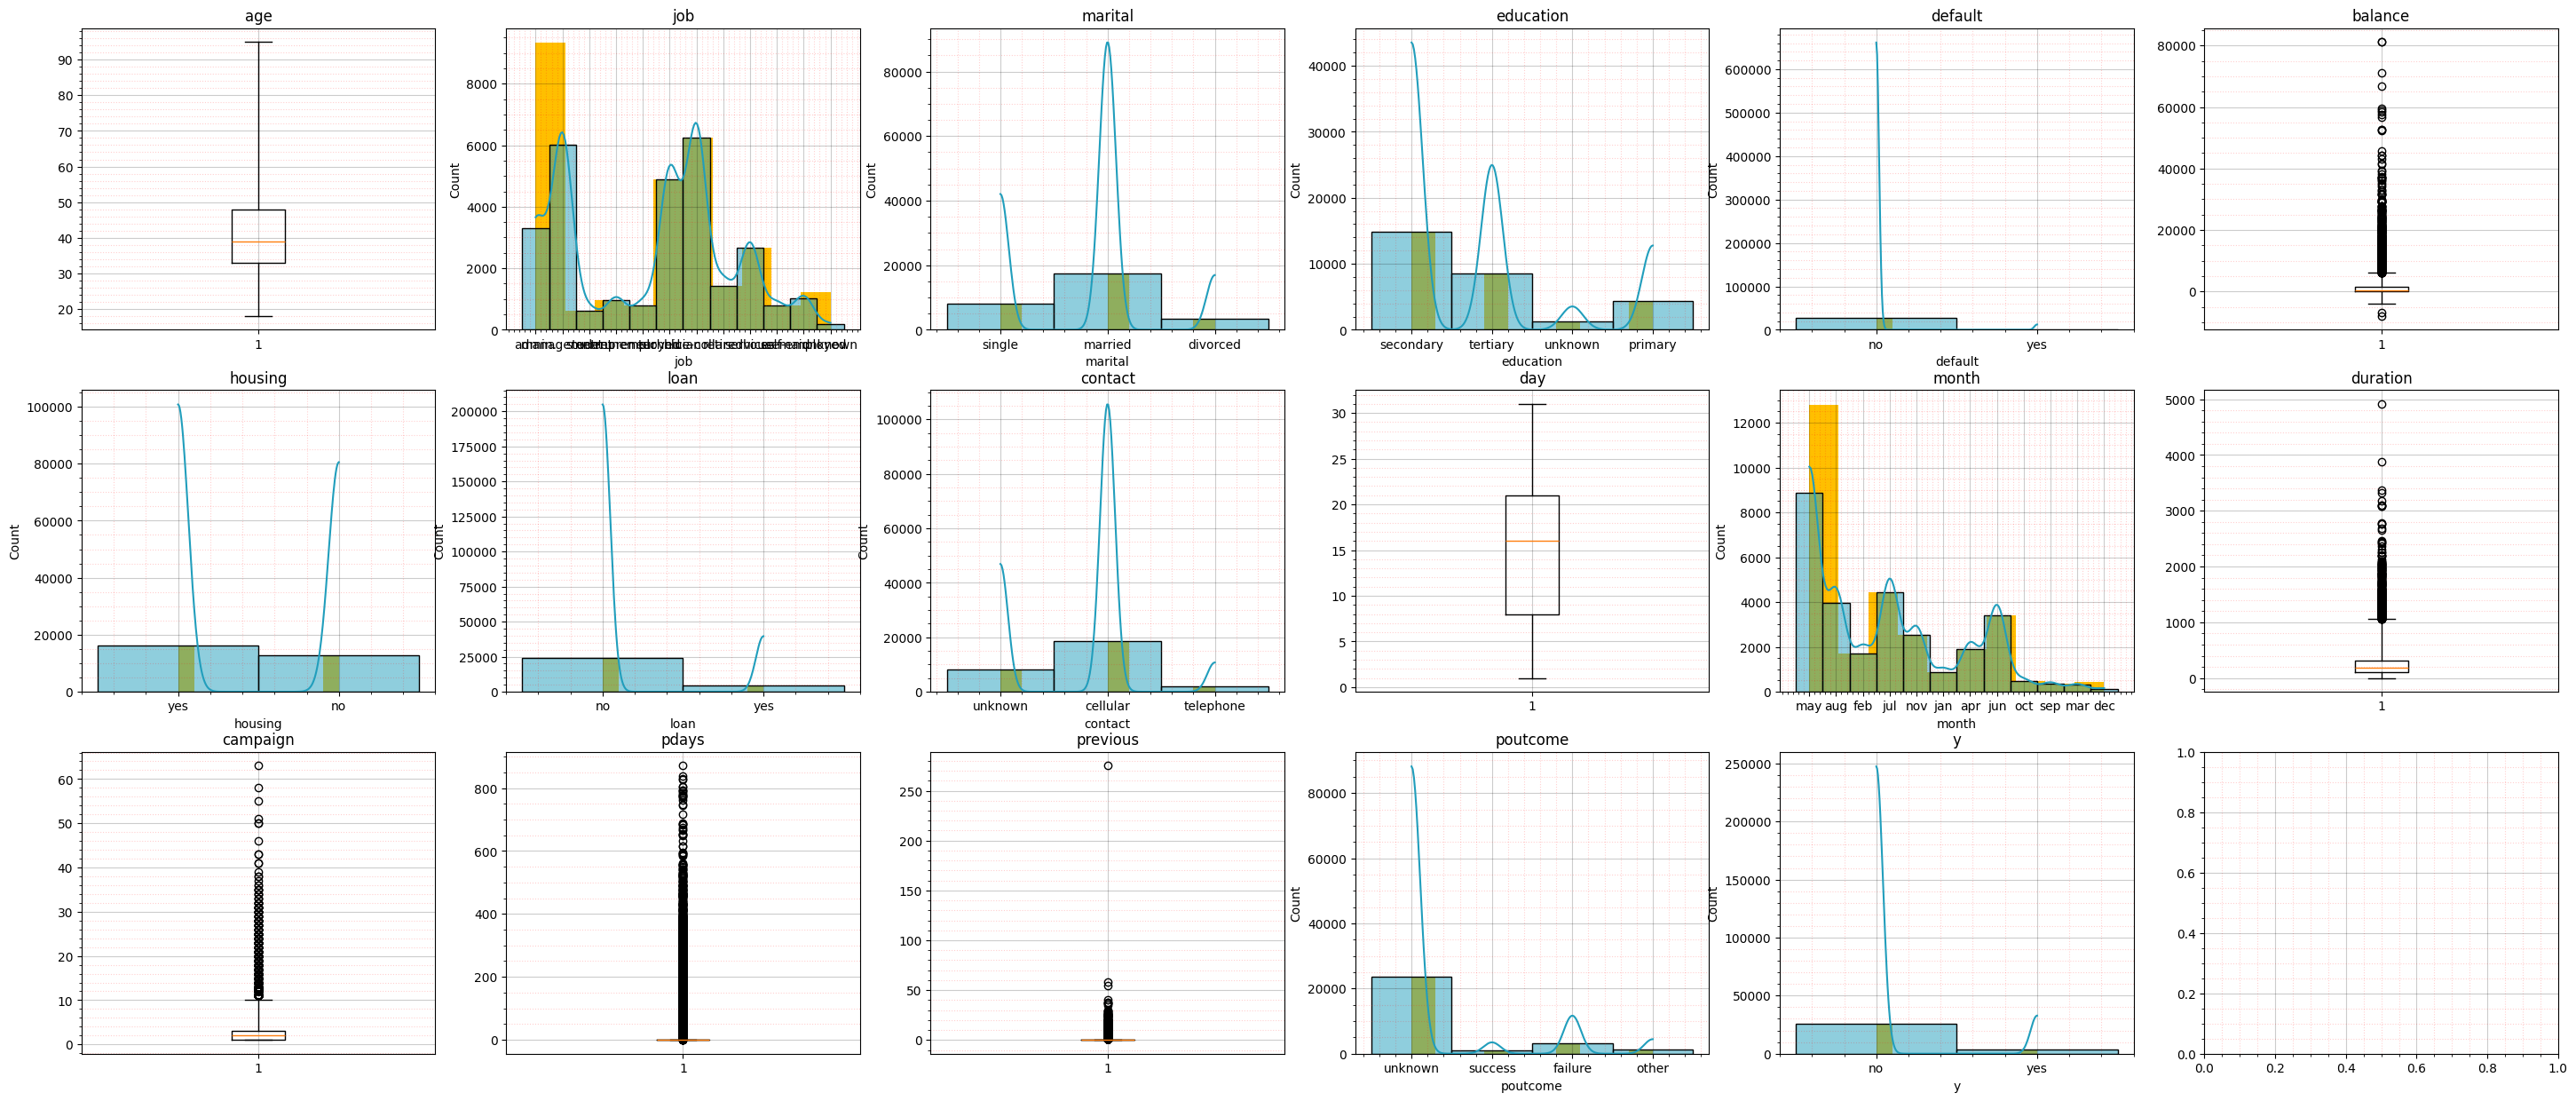

In [58]:
fig3, axs3 = plt.subplots(3, 6, figsize=(36, 15))

for i, e in enumerate([0, 6, 12]):
    for j in range(6):
        axs3[i, j].grid(which='minor', ls = ':', c = '#FF1111', alpha = 0.2)
        axs3[i, j].grid(c = 'k', alpha = 0.2)
        axs3[i, j].minorticks_on()
        
        if ((j + e) < train_set.shape[1]) :
            if (train_set.iloc[:, j+e].dtype == 'category') :
                axs3[i, j].hist(train_set.iloc[:, j+e], color = '#FFBF00')
                axs3[i, j].set_title(train_set.columns[j+e])
                sns.histplot(train_set.iloc[:, j+e], color = '#219ebc', bins=50, kde=True, ax=axs3[i, j])

            elif(train_set.iloc[:, j+e].dtype != 'category'):
                axs3[i, j].boxplot(train_set.iloc[:, j+e], whis=3.5)
                axs3[i, j].set_title(train_set.columns[j+e])

In [59]:
flage_age = train_set[(train_set.age > des_train.loc['Upper cap', 'age']) | (train_set.age < des_train.loc['Lower cap', 'age'])]
flage_age

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y


In [60]:
flage_balance = train_set[(train_set.balance > des_train.loc['Upper cap', 'balance']) | (train_set.balance < des_train.loc['Lower cap', 'balance'])]
flage_balance

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
38369,35,management,single,tertiary,no,6781,yes,no,cellular,15,may,19,6,-1,0,unknown,no
22927,54,blue-collar,married,primary,no,7073,no,no,cellular,26,aug,479,6,-1,0,unknown,no
20986,47,admin.,married,secondary,no,6703,no,no,cellular,14,aug,252,3,-1,0,unknown,no
24097,57,technician,married,secondary,no,7554,no,no,telephone,28,oct,141,1,-1,0,unknown,yes
16883,39,entrepreneur,married,primary,no,13930,yes,no,cellular,25,jul,337,2,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8182,34,blue-collar,married,secondary,no,8558,yes,no,unknown,2,jun,466,2,-1,0,unknown,no
35064,55,admin.,married,secondary,no,6205,no,no,cellular,6,may,233,2,-1,0,unknown,no
40161,42,unemployed,single,primary,no,8037,no,no,cellular,5,jun,92,2,-1,0,unknown,no
20328,51,technician,single,secondary,no,8538,yes,no,cellular,11,aug,126,2,-1,0,unknown,no


In [61]:
flage_duration = train_set[(train_set.duration > des_train.loc['Upper cap', 'duration']) | (train_set.duration < des_train.loc['Lower cap', 'duration'])]
flage_duration

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
27777,49,technician,married,secondary,no,808,yes,no,cellular,28,jan,1232,1,-1,0,unknown,yes
22907,34,technician,married,secondary,no,1035,no,no,cellular,25,aug,1374,10,-1,0,unknown,yes
26951,37,technician,single,tertiary,no,6889,yes,no,cellular,21,nov,1221,1,-1,0,unknown,no
11420,40,blue-collar,married,secondary,no,273,yes,no,unknown,19,jun,1082,1,-1,0,unknown,no
35080,31,management,single,tertiary,no,59,yes,yes,cellular,6,may,1347,2,363,1,failure,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31660,37,admin.,married,secondary,no,1207,yes,no,telephone,6,apr,1353,2,138,2,success,yes
25167,36,services,married,secondary,no,0,yes,no,cellular,18,nov,1093,2,-1,0,unknown,no
9671,36,self-employed,married,secondary,no,1245,yes,no,unknown,6,jun,1469,9,-1,0,unknown,yes
20567,46,self-employed,married,secondary,no,548,no,no,cellular,12,aug,1181,4,-1,0,unknown,yes


In [62]:
flage_campaign = train_set[(train_set.campaign > des_train.loc['Upper cap', 'campaign']) | (train_set.campaign < des_train.loc['Lower cap', 'campaign'])]
flage_campaign

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
22596,55,blue-collar,married,secondary,no,176,no,yes,cellular,22,aug,140,11,-1,0,unknown,no
9428,34,technician,married,secondary,no,139,yes,yes,unknown,6,jun,52,13,-1,0,unknown,no
23763,36,technician,married,secondary,no,4542,yes,no,cellular,28,aug,76,16,-1,0,unknown,no
22948,39,management,married,tertiary,no,309,no,no,cellular,26,aug,94,14,-1,0,unknown,no
20855,55,technician,married,secondary,no,199,no,no,cellular,13,aug,15,17,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22056,34,technician,single,secondary,no,10890,no,no,cellular,20,aug,46,14,-1,0,unknown,no
12017,38,blue-collar,married,secondary,no,2685,no,no,unknown,20,jun,22,12,-1,0,unknown,no
23636,60,self-employed,married,secondary,no,1690,no,no,cellular,28,aug,64,11,-1,0,unknown,no
17727,49,admin.,divorced,secondary,no,124,yes,yes,cellular,29,jul,125,19,-1,0,unknown,no


In [63]:
flage_previous = train_set[(train_set.previous > des_train.loc['Upper cap', 'previous']) | (train_set.previous < des_train.loc['Lower cap', 'previous'])]
flage_previous

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
44371,32,technician,single,tertiary,no,388,no,no,cellular,2,aug,100,8,95,3,success,no
38321,35,technician,single,secondary,no,-89,yes,no,cellular,15,may,75,1,368,1,failure,no
32287,46,blue-collar,single,primary,no,96,yes,no,cellular,16,apr,99,1,148,1,failure,no
36830,33,management,divorced,tertiary,no,-634,yes,yes,cellular,12,may,163,2,350,1,failure,no
37387,44,blue-collar,married,tertiary,no,1371,no,no,cellular,13,may,788,3,363,4,other,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31667,46,admin.,single,secondary,no,757,yes,yes,cellular,6,apr,342,3,256,3,failure,no
30189,54,blue-collar,married,secondary,no,844,no,no,telephone,5,feb,8,7,189,18,other,no
34651,55,services,married,secondary,no,-626,yes,yes,cellular,5,may,369,2,278,5,failure,no
35805,42,management,married,tertiary,no,4,yes,no,cellular,8,may,579,2,295,1,success,yes


In [64]:
col_num = des_train.columns
flage_all = (train_set[col_num] > des_train.loc['Upper cap']) | (train_set[col_num] < des_train.loc['Lower cap'])
flage_all.sum(axis=1).astype(np.bool_).sum(), flage_all.sum()

(np.int64(7486),
 age            0
 balance     1322
 day            0
 duration     577
 campaign     764
 pdays       5268
 previous    5268
 dtype: int64)

In [67]:
powert = PowerTransformer()
train_numeric_tra = train_numeric.copy()
train_numeric_tra.iloc[:, :] = powert.fit_transform(train_numeric)
train_set_e.loc[:, col_num] = powert.fit_transform(train_set_e.loc[:, col_num])

C:\Users\Ertebatat-Sahar\AppData\Local\Temp\ipykernel_20460\1044438722.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.59213998  0.05396331 -0.8370601  ...  0.91605775  0.91605775
 -0.04568227]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_numeric_tra.iloc[:, :] = powert.fit_transform(train_numeric)
C:\Users\Ertebatat-Sahar\AppData\Local\Temp\ipykernel_20460\1044438722.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.43198689 -0.4235386   0.17236483 ...  0.37514412  0.19712084
 -0.41279591]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_numeric_tra.iloc[:, :] = powert.fit_transform(train_numeric)
C:\Users\Ertebatat-Sahar\AppData\Local\Temp\ipykernel_20460\1044438722.py:3: FutureWarning: Setting an item of incompatible dtype is depre

In [73]:
flage_del_out_bal = train_numeric_tra.balance < -20
flage_del_out_bal2 = train_set_e.balance < -20

train_numeric_tra = train_numeric_tra[~flage_del_out_bal]
train_set_e = train_set_e[~flage_del_out_bal2]

In [74]:
train_set_e.shape, train_numeric_tra.shape

((28932, 31), (28932, 7))

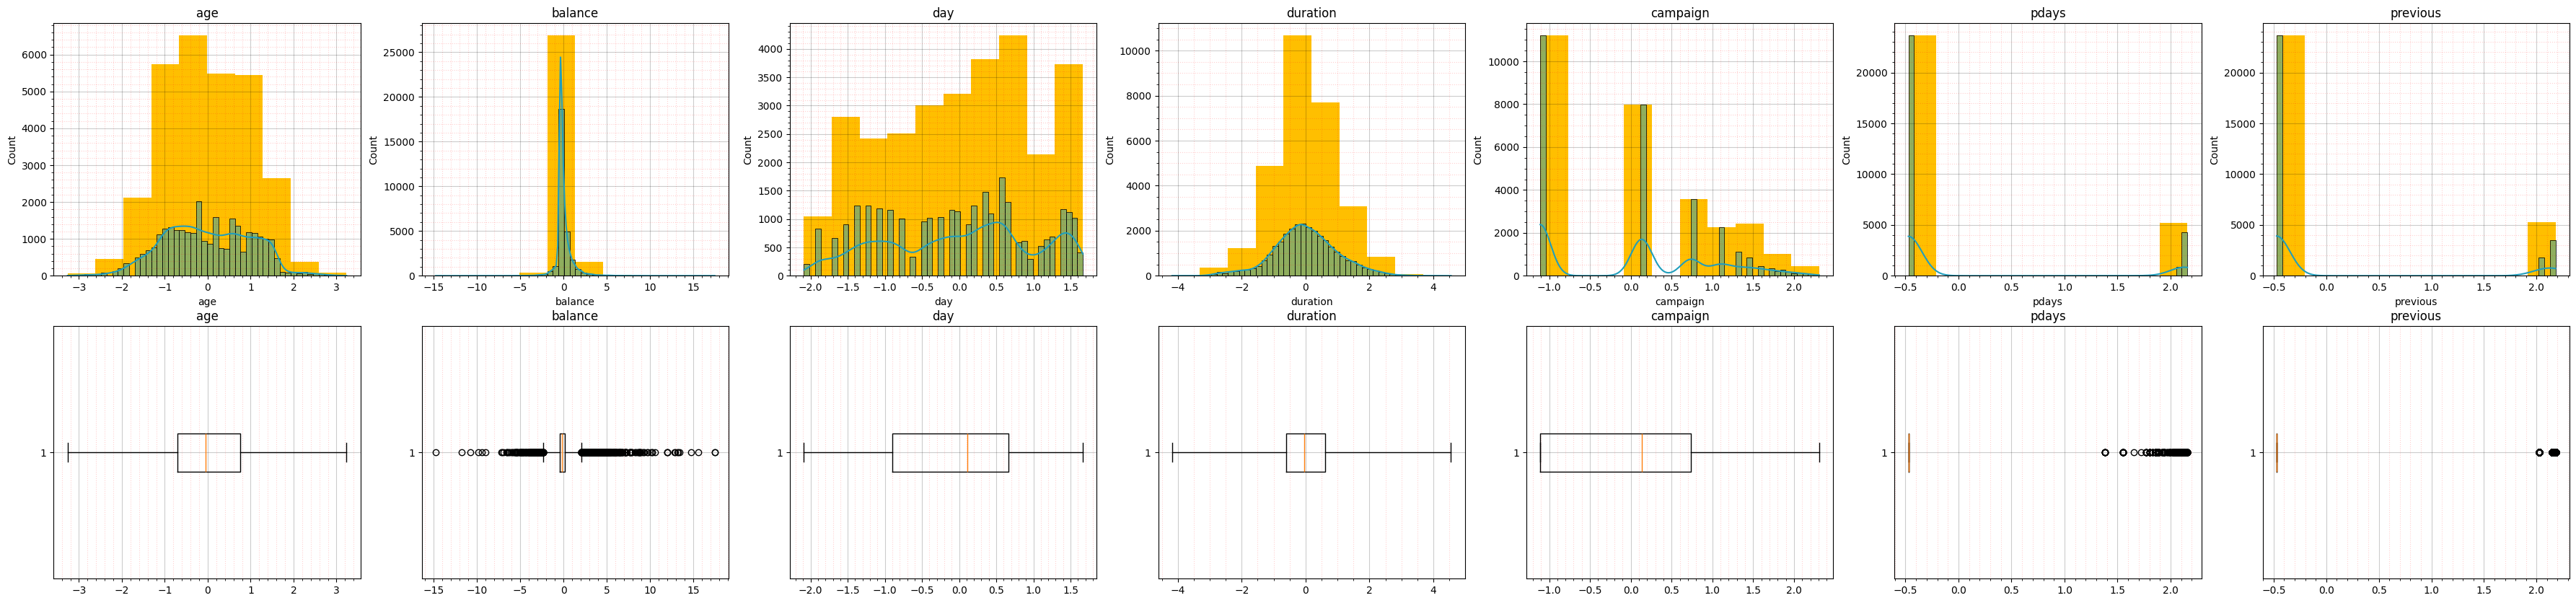

In [75]:
fig6, axs6 = plt.subplots(2, 7, figsize=(45, 10))

for i in range(2):
    for j in range(7):
        axs6[i, j].grid(which='minor', ls = ':', c = '#FF1111', alpha = 0.2)
        axs6[i, j].grid(c = 'k', alpha = 0.2)
        axs6[i, j].minorticks_on()

        if (j) < train_numeric_tra.shape[1] :
            if i == 0:
                axs6[i, j].hist(train_numeric_tra.iloc[:, j], color = '#FFBF00')
                sns.histplot(train_numeric_tra.iloc[:, j], color = '#219ebc', bins=50, kde=True, ax=axs6[i, j])
                axs6[i, j].set_title(train_numeric_tra.columns[j])
            else :
                axs6[i, j].boxplot(train_numeric_tra.iloc[:, j], vert=False, whis=3.5)
                axs6[i, j].set_title(train_numeric_tra.columns[j])

## Feature / Data Reduction :

## Feature Transform :

## Data Normalization :

### Normalization :

In [76]:
normalizer = MinMaxScaler()
train_set_eN = train_set_e.copy()
train_set_eN.iloc[:, :-1] = normalizer.fit_transform(train_set_e.iloc[:, :-1])

In [77]:
train_set_eN.describe()

,age,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,...,contact_cellular,contact_telephone,contact_unknown,day,month,duration,campaign,pdays,previous,y_yes
count,28932.000000,28932.000000,28932.000000,28932.000000,28932.000000,28932.000000,28932.000000,28932.000000,28932.000000,28932.000000,...,28932.000000,28932.000000,28932.000000,28932.000000,28932.000000,28932.000000,28932.000000,28932.000000,28932.000000,28932.000000
mean,0.502222,0.114372,0.215609,0.033700,0.027202,0.208316,0.048977,0.035566,0.091940,0.021222,...,0.647138,0.065740,0.287122,0.556408,0.502485,0.478615,0.324579,0.179382,0.177861,0.116998
std,0.153891,0.318268,0.411251,0.180458,0.162674,0.406111,0.215824,0.185209,0.288946,0.144127,...,0.477868,0.247832,0.452427,0.266309,0.273057,0.114589,0.292638,0.380324,0.377130,0.321424
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.392572,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.315704,0.272727,0.408286,0.000000,0.000000,0.000000,0.000000
50%,0.495188,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.585052,0.545455,0.474781,0.363498,0.000000,0.000000,0.000000
75%,0.619256,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,1.000000,0.732701,0.727273,0.548875,0.540103,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Standardization :

In [79]:
standarder = StandardScaler()
train_set_eS = train_set_e.copy()
train_set_eS.iloc[:, :-1] = standarder.fit_transform(train_set_e.iloc[:, :-1])

In [80]:
train_set_eS.describe()

,age,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,...,contact_cellular,contact_telephone,contact_unknown,day,month,duration,campaign,pdays,previous,y_yes
count,2.893200e+04,2.893200e+04,2.893200e+04,2.893200e+04,2.893200e+04,2.893200e+04,2.893200e+04,2.893200e+04,2.893200e+04,2.893200e+04,...,2.893200e+04,2.893200e+04,2.893200e+04,2.893200e+04,2.893200e+04,2.893200e+04,2.893200e+04,2.893200e+04,2.893200e+04,28932.000000
mean,1.178835e-17,-4.346954e-17,2.161197e-17,-3.094442e-17,-1.031481e-17,9.430679e-17,8.251844e-17,-2.112079e-17,1.841930e-17,-3.782095e-17,...,-4.469749e-17,1.129717e-17,9.823624e-18,2.652379e-17,-4.469749e-17,-1.817370e-17,7.465954e-17,7.858899e-17,2.210315e-17,0.116998
std,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,...,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,1.000017e+00,0.321424
min,-3.263551e+00,-3.593630e-01,-5.242847e-01,-1.867485e-01,-1.672194e-01,-5.129623e-01,-2.269343e-01,-1.920358e-01,-3.181957e-01,-1.472492e-01,...,-1.354241e+00,-2.652664e-01,-6.346366e-01,-2.089370e+00,-1.840252e+00,-4.176862e+00,-1.109169e+00,-4.716629e-01,-4.716254e-01,0.000000
25%,-7.125293e-01,-3.593630e-01,-5.242847e-01,-1.867485e-01,-1.672194e-01,-5.129623e-01,-2.269343e-01,-1.920358e-01,-3.181957e-01,-1.472492e-01,...,-1.354241e+00,-2.652664e-01,-6.346366e-01,-9.038693e-01,-8.414433e-01,-6.137566e-01,-1.109169e+00,-4.716629e-01,-4.716254e-01,0.000000
50%,-4.571297e-02,-3.593630e-01,-5.242847e-01,-1.867485e-01,-1.672194e-01,-5.129623e-01,-2.269343e-01,-1.920358e-01,-3.181957e-01,-1.472492e-01,...,7.384207e-01,-2.652664e-01,-6.346366e-01,1.075600e-01,1.573657e-01,-3.345399e-02,1.329970e-01,-4.716629e-01,-4.716254e-01,0.000000
75%,7.605080e-01,-3.593630e-01,-5.242847e-01,-1.867485e-01,-1.672194e-01,-5.129623e-01,-2.269343e-01,-1.920358e-01,-3.181957e-01,-1.472492e-01,...,7.384207e-01,-2.652664e-01,1.575705e+00,6.619980e-01,8.232383e-01,6.131569e-01,7.364995e-01,-4.716629e-01,-4.716254e-01,0.000000
max,3.234667e+00,2.782701e+00,1.907361e+00,5.354797e+00,5.980166e+00,1.949461e+00,4.406561e+00,5.207362e+00,3.142720e+00,6.791209e+00,...,7.384207e-01,3.769795e+00,1.575705e+00,1.665735e+00,1.822047e+00,4.550117e+00,2.308083e+00,2.157719e+00,2.180024e+00,1.000000


## Balansing Data :

## Save DataBase :

In [82]:
train_set_eN.to_csv('../data/train_set_eN.csv')
train_set_eS.to_csv('../data/train_set_eS.csv')

# Preprocess vallid data :

## Missing values :

In [84]:
vall_set.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

<Axes: >

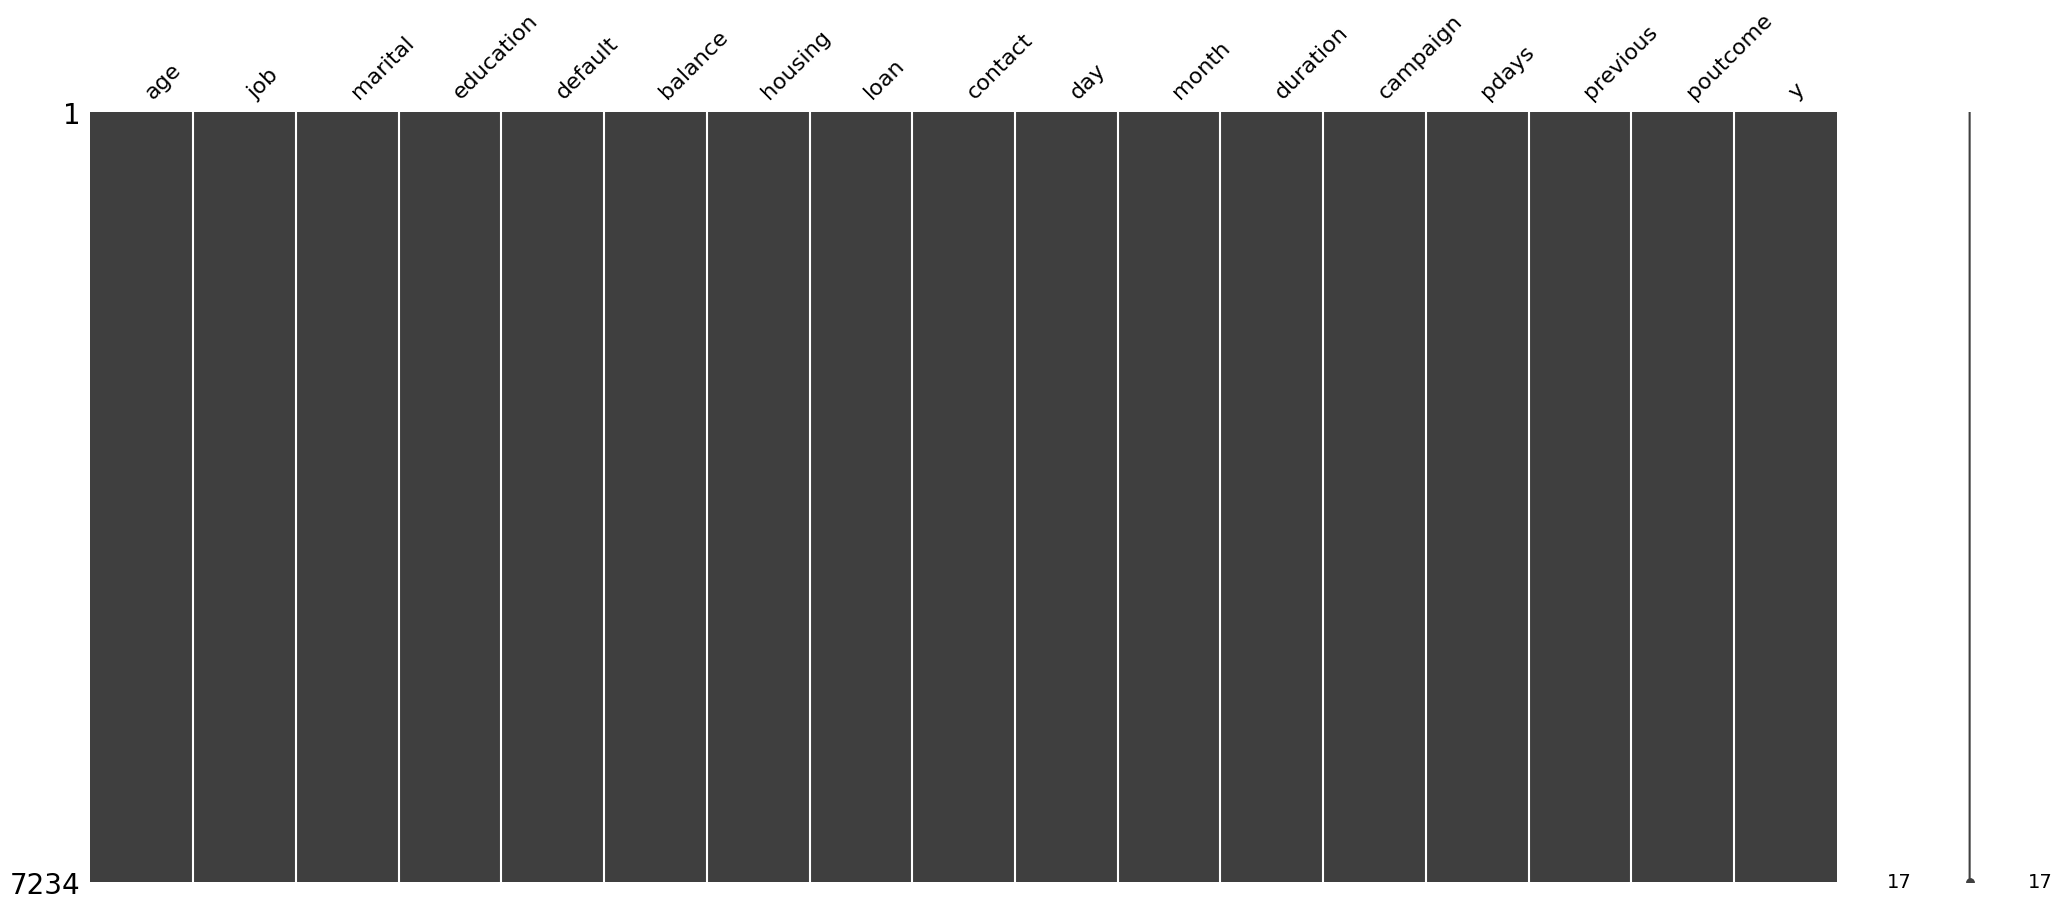

In [85]:
msno.matrix(vall_set)

## Data Encoding :

In [87]:
vall_set_e = vall_set.copy()
vall_set_e = pd.get_dummies(vall_set, columns=['job', 'marital', 'contact', 'poutcome'], dtype=np.float64)

In [88]:
encoder.fit(train_set.education)
vall_set_e.education = encoder.transform(vall_set_e.education)

In [89]:
encoder.fit(train_set.month)
vall_set_e.month = encoder.transform(vall_set_e.month)

In [90]:
vall_set_e = pd.get_dummies(vall_set_e, columns=['default', 'housing', 'loan'], dtype=np.float64, drop_first=True)

In [91]:
vall_set_e = pd.get_dummies(vall_set_e, columns=['y'], dtype=np.float64, drop_first=True)

In [92]:
vall_set_e = vall_set_e.reindex(columns=sort_columns)

In [93]:
vall_set_e

,age,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,...,contact_cellular,contact_telephone,contact_unknown,day,month,duration,campaign,pdays,previous,y_yes
15243,41,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,17,5,122,17,-1,0,0.0
20759,47,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,13,1,334,2,-1,0,0.0
41314,36,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,27,1,398,2,477,1,1.0
31362,27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,18,7,236,2,-1,0,0.0
4976,36,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,21,8,17,2,-1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43943,24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,17,6,21,1,-1,0,0.0
27167,40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,21,9,365,1,100,2,0.0
10957,35,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,17,6,495,2,-1,0,0.0
42641,31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,13,4,262,1,-1,0,0.0


In [94]:
vall_set_e[vall_set_e.dtypes[vall_set_e.dtypes == np.int64].index] = vall_set_e[vall_set_e.dtypes[vall_set_e.dtypes == np.int64].index].astype(np.float64)

In [95]:
vall_set_e.dtypes

age                  float64
job_admin.           float64
job_blue-collar      float64
job_entrepreneur     float64
job_housemaid        float64
job_management       float64
job_retired          float64
job_self-employed    float64
job_services         float64
job_student          float64
job_technician       float64
job_unemployed       float64
job_unknown          float64
marital_divorced     float64
marital_married      float64
marital_single       float64
education            float64
default_yes          float64
balance              float64
housing_yes          float64
loan_yes             float64
contact_cellular     float64
contact_telephone    float64
contact_unknown      float64
day                  float64
month                float64
duration             float64
campaign             float64
pdays                float64
previous             float64
y_yes                float64
dtype: object

## Outliers :

In [97]:
vall_set_e.loc[:, col_num] = powert.transform(vall_set_e.loc[:, col_num])

In [99]:
vall_set_e

,age,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,...,contact_cellular,contact_telephone,contact_unknown,day,month,duration,campaign,pdays,previous,y_yes
15243,0.150789,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.222122,5.0,-0.449495,2.065323,-0.471643,-0.471605,0.0
20759,0.679919,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,-0.249448,1.0,0.675397,0.133010,-0.471643,-0.471605,0.0
41314,-0.363161,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.277956,1.0,0.887542,0.133010,2.148923,2.024904,1.0
31362,-1.534603,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.334714,7.0,0.269766,0.133010,-0.471643,-0.471605,0.0
4976,-0.363161,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.662017,8.0,-2.228655,0.133010,-0.471643,-0.471605,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43943,-2.027678,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.222122,6.0,-2.063460,-1.109160,-0.471643,-0.471605,0.0
27167,0.053963,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.662017,9.0,0.782171,-1.109160,2.103441,2.150610,0.0
10957,-0.475779,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.222122,6.0,1.158603,0.133010,-0.471643,-0.471605,0.0
42641,-0.966163,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,-0.249448,4.0,0.389814,-1.109160,-0.471643,-0.471605,0.0


## Data Normalization :

### Normalization :

In [100]:
vall_set_eN = vall_set_e.copy()
vall_set_eN.iloc[:, :-1] = normalizer.transform(vall_set_e.iloc[:, :-1])

### Standardization :

In [102]:
vall_set_eS = vall_set_e.copy()
vall_set_eS.iloc[:, :-1] = standarder.transform(vall_set_e.iloc[:, :-1])

## Save DataBase :

In [104]:
vall_set_eN.to_csv("../data/vall_set_eN.csv")
vall_set_eS.to_csv("../data/vall_set_eS.csv")

# Preprocess test data :

## Missing values :

In [105]:
test_set.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

<Axes: >

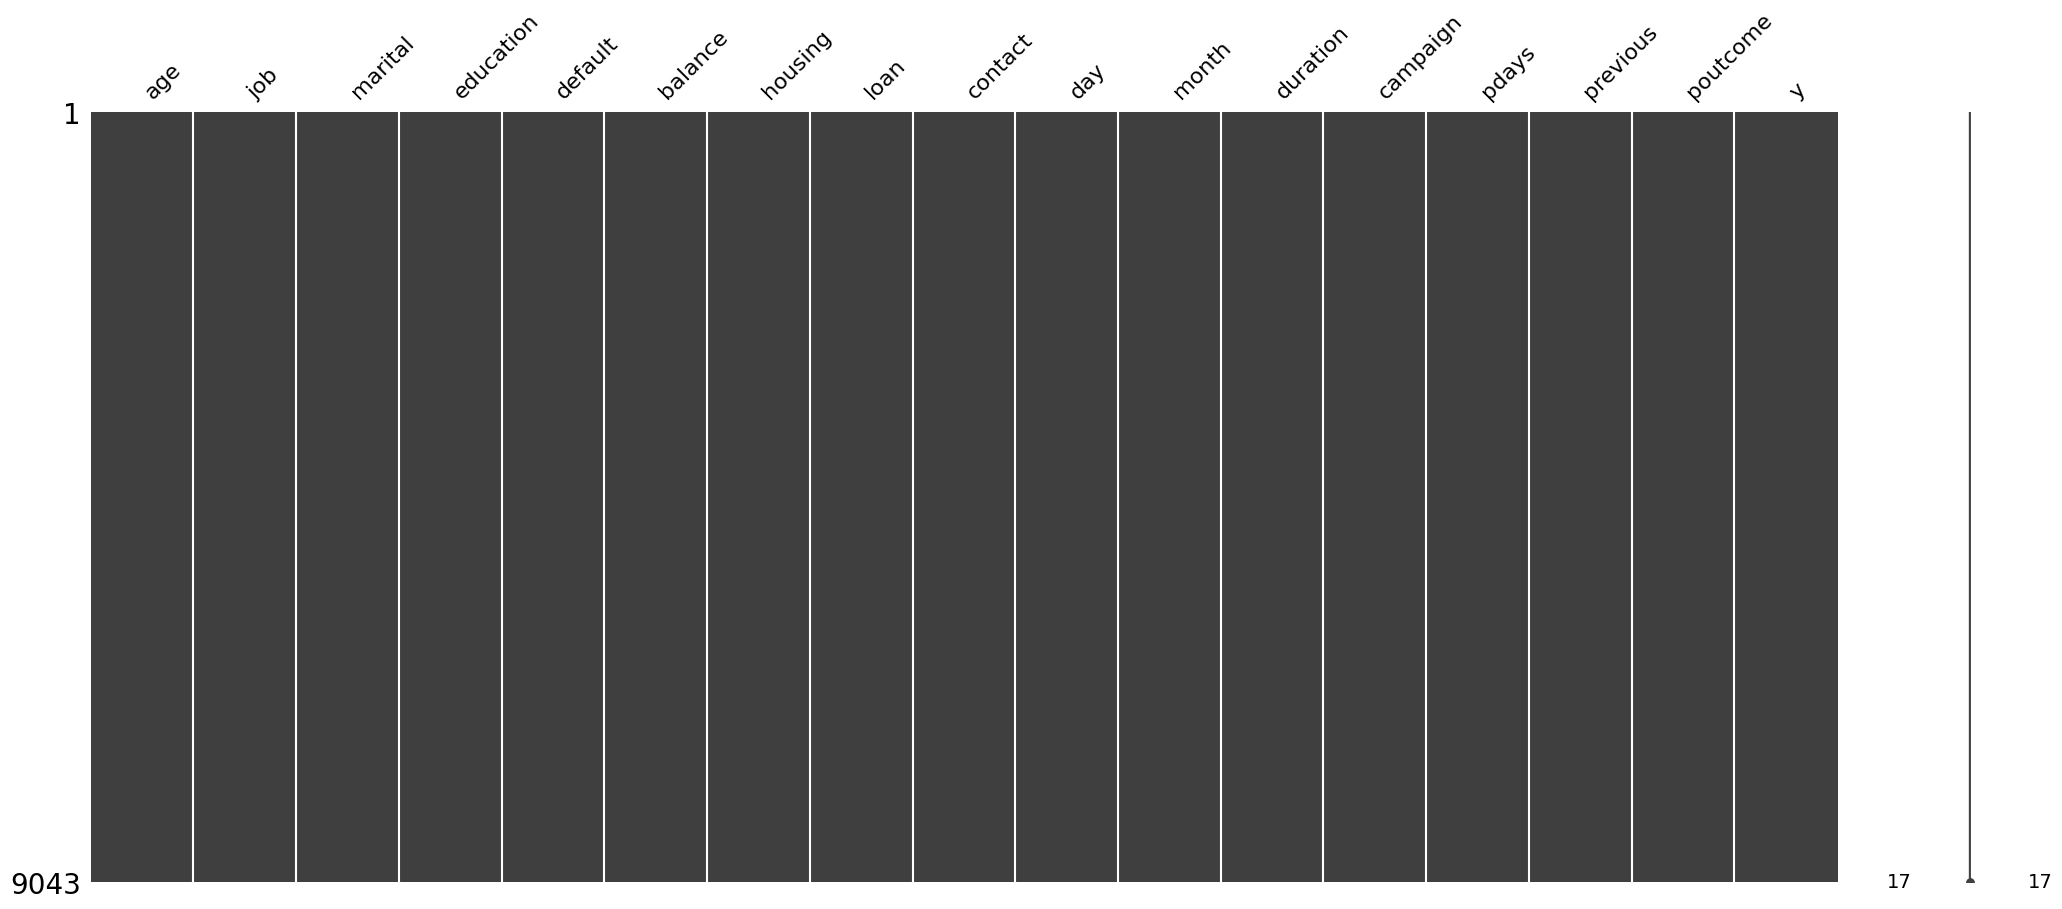

In [106]:
msno.matrix(test_set)

## Data Encoding :

In [108]:
test_set_e = test_set.copy()
test_set_e = pd.get_dummies(test_set, columns=['job', 'marital', 'contact', 'poutcome'], dtype=np.float64)

In [109]:
encoder.fit(train_set.education)
test_set_e.education = encoder.transform(test_set_e.education)

In [110]:
encoder.fit(train_set.month)
test_set_e.month = encoder.transform(test_set_e.month)

In [111]:
test_set_e = pd.get_dummies(test_set_e, columns=['default', 'housing', 'loan'], dtype=np.float64, drop_first=True)

In [112]:
test_set_e = pd.get_dummies(test_set_e, columns=['y'], dtype=np.float64, drop_first=True)

In [113]:
test_set_e = test_set_e.reindex(columns=sort_columns)

In [114]:
test_set_e

,age,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,...,contact_cellular,contact_telephone,contact_unknown,day,month,duration,campaign,pdays,previous,y_yes
3372,35,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,15,8,136,1,-1,0,0.0
27096,34,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,21,9,963,1,-1,0,1.0
33347,36,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,20,0,15,6,152,21,0.0
38661,34,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,15,8,22,8,331,13,0.0
7568,42,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,30,8,204,4,-1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38214,37,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,15,8,7,6,357,1,0.0
43560,37,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,27,0,426,2,179,3,1.0
22524,46,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,22,1,234,4,-1,0,0.0
32726,36,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,17,0,382,2,-1,0,0.0


In [115]:
test_set_e[test_set_e.dtypes[test_set_e.dtypes == np.int64].index] = test_set_e[test_set_e.dtypes[test_set_e.dtypes == np.int64].index].astype(np.float64)

In [116]:
test_set_e.dtypes

age                  float64
job_admin.           float64
job_blue-collar      float64
job_entrepreneur     float64
job_housemaid        float64
job_management       float64
job_retired          float64
job_self-employed    float64
job_services         float64
job_student          float64
job_technician       float64
job_unemployed       float64
job_unknown          float64
marital_divorced     float64
marital_married      float64
marital_single       float64
education            float64
default_yes          float64
balance              float64
housing_yes          float64
loan_yes             float64
contact_cellular     float64
contact_telephone    float64
contact_unknown      float64
day                  float64
month                float64
duration             float64
campaign             float64
pdays                float64
previous             float64
y_yes                float64
dtype: object

## Outliers :

In [119]:
test_set_e.loc[:, col_num] = powert.transform(test_set_e.loc[:, col_num])

In [121]:
test_set_e

,age,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,...,contact_cellular,contact_telephone,contact_unknown,day,month,duration,campaign,pdays,previous,y_yes
3372,-0.475779,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,-0.009083,8.0,-0.335556,-1.109160,-0.471643,-0.471605,0.0
27096,-0.592140,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.662017,9.0,2.036702,-1.109160,-0.471643,-0.471605,1.0
33347,-0.363161,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.554549,0.0,-2.323577,1.487420,2.120016,2.180107,0.0
38661,-0.592140,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,-0.009083,8.0,-2.026265,1.702328,2.141733,2.180061,0.0
7568,0.244939,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.570292,8.0,0.105239,1.091103,-0.471643,-0.471605,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38214,-0.254068,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,-0.009083,8.0,-2.852985,1.487420,2.143353,2.024904,0.0
43560,-0.254068,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.277956,0.0,0.971180,0.133010,2.125451,2.171030,1.0
22524,0.597320,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.767980,1.0,0.260066,1.091103,-0.471643,-0.471605,0.0
32726,-0.363161,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.222122,0.0,0.837436,0.133010,-0.471643,-0.471605,0.0


## Data Normalization :

### Normalization :

In [124]:
test_set_eN = test_set_e.copy()
test_set_eN.iloc[:, :-1] = normalizer.transform(test_set_eN.iloc[:, :-1])

In [125]:
test_set_eN.shape

(9043, 31)

### Standardization :

In [126]:
test_set_eS = test_set_e.copy()
test_set_eS.iloc[:, :-1] = standarder.transform(test_set_eS.iloc[:, :-1])

## Save DataBase :

In [128]:
test_set_eN.to_csv("../data/test_set_eN.csv")
test_set_eS.to_csv("../data/test_set_eS.csv")